<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Google_playstore_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Code Cell

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

# Show plots inline (Colab does this by default)
# %matplotlib inline

# Dataset Load Code Cell

In [2]:
!kaggle datasets download -d lava18/google-play-store-apps
!unzip -q google-play-store-apps.zip -d ./data

Dataset URL: https://www.kaggle.com/datasets/lava18/google-play-store-apps
License(s): CC-BY-SA-4.0
100% 1.94M/1.94M [00:00<00:00, 109MB/s]



In [3]:
!ls

data  google-play-store-apps.zip  sample_data


In [4]:
!unzip -q google-play-store-apps.zip -d ./data

replace ./data/googleplaystore.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./data/googleplaystore_user_reviews.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./data/license.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [5]:
df = pd.read_csv('./data/googleplaystore.csv')  # ya ./data/folder_name/googleplaystore.csv

In [6]:
# Check all column names
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
# Check dataset shape
df.shape

(10841, 13)

Not enough, let's have a look on the columns and their data types using detailed info function

In [8]:
# Check dataset info: columns, data types, missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## 📝 Observations

- The dataset contains **10,841 rows** and **13 columns**.  
- Columns have **different data types** (numeric, object, etc.).  
- Column names:  
  `App`, `Category`, `Rating`, `Reviews`, `Size`, `Installs`, `Type`, `Price`, `Content Rating`, `Genres`, `Last Updated`, `Current Ver`, `Android Ver`.
- Some columns have **missing values**, which we will handle during data cleaning.  
- Certain columns like `Size`, `Installs`, and `Price` are currently **object type** but should be **numeric**, we will convert them in the next steps.  

In [9]:
# Summary statistics of numeric columns
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## 📝 Observations

- Currently, only **`Rating`** and **`Reviews`** columns are numeric.  
- Most other columns are of **object type** according to Python.  
- Columns like **`Size`**, **`Installs`**, and **`Price`** are actually numeric, so we will **convert them to numeric types** during the data wrangling process.

In [11]:
# Check number of missing values in 'Size' column
df['Size'].isnull().sum()

np.int64(0)

Ready for full cleaning + conversion block

In [12]:
# Check unique values in 'Size' column
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

Steps to Clean Size Column
Replace 'Varies with device' with NaN → taake numeric conversion easy ho.
Convert M → bytes, K → bytes.
Remove 'M' and 'K' characters and multiply by correct factor.
Convert the column to float type.


In [13]:
# find the values in size column which has 'M' in it
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()

np.int64(8829)

## 📝 Observation: Size Column

- The `Size` column contains values in different units like **M (megabytes)** and **K (kilobytes)**.  
- To analyze the data consistently, we need to:  
  1. Replace `'Varies with device'` with `NaN`.  
  2. Convert all sizes to a **common unit (bytes)**.  
  3. Remove the `'M'` and `'K'` characters.  
  4. Convert the column to **numeric type**.  

> This will allow us to perform meaningful analysis and visualization on app sizes.

In [15]:
# Count values in 'Size' column that contain 'k'
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

## 📝 Observation: Size Column in Kilobytes

- The `Size` column also contains some values in **kilobytes (k)**.  
- Similar to megabytes, these values need to be **converted to bytes** for consistent analysis.  

In [16]:
# Count values in 'Size' column that contain 'Varies with device'
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts().sum()

np.int64(1695)

In [17]:
# Total Values in Size column
df['Size'].value_counts().sum()

np.int64(10841)

## 📝 Observation: Size Column with 'Varies with device'

- Some apps have **Size listed as 'Varies with device'**.  
- These values cannot be converted directly to numeric, so we will replace them with **NaN** during data cleaning.  
- This ensures consistent numeric analysis for app sizes.

In [18]:
# taking sum of all the values in size column which has 'M', 'K' and 'varies with device' in it
8830+316+1695

10841

## 📝 Observation: Size Column Summary

- The `Size` column contains **8,830 values in megabytes (M)**, **316 values in kilobytes (K)**, and **1,695 values listed as 'Varies with device'**.  
- To make the `Size` column consistent for analysis, we will:  
  1. Convert **M → bytes** and **K → bytes**.  
  2. Remove the `M` and `K` characters.  
  3. Replace `'Varies with device'` with `NaN`.  
  4. Convert the column to **numeric type**.  

> This will allow us to perform accurate calculations and visualizations for app sizes.

In [19]:
import numpy as np

def convert_size(size):
    """
    Converts the 'Size' column to numeric bytes:
    - 'k' → multiply by 1024
    - 'M' → multiply by 1024*1024
    - 'Varies with device' → NaN
    """
    if isinstance(size, str):
        size = size.strip()  # remove extra spaces
        if 'k' in size.lower():  # handle lowercase 'k'
            return float(size.lower().replace('k','')) * 1024
        elif 'M' in size.upper():  # handle uppercase 'M'
            return float(size.upper().replace('M','')) * 1024 * 1024
        elif 'Varies with device' in size:
            return np.nan
    return np.nan  # for any other unexpected value

# Apply function
df['Size'] = df['Size'].apply(convert_size)

# Check first 5 rows
df['Size'].head()

,Size
0,19922944.0
1,14680064.0
2,9122611.2
3,26214400.0
4,2936012.8


## 📝 Observation: Size Column Conversion

- The `Size` column contained values in **megabytes (M)**, **kilobytes (k)**, and **'Varies with device'**.  
- We converted all values to **numeric bytes** for consistent analysis:  
  - `'M'` → multiplied by 1024 × 1024  
  - `'k'` → multiplied by 1024  
  - `'Varies with device'` → replaced with `NaN`  
- Now the column is **numeric** and ready for calculations, visualizations, and further analysis.

In [20]:
# Rename the column from 'Size' to 'Size_in_bytes'
df.rename(columns={'Size': 'Size_in_bytes'}, inplace=True)

# Check the columns
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

## 📝 Observation: Column Renaming

- The `Size` column has been renamed to **`Size_in_bytes`**.  
- This makes it **clear and self-explanatory** that the values are in bytes.  
- Helps improve **readability and professionalism** for clients or GitHub/LinkedIn showcase.

In [21]:
# Create a new column 'Size_in_Mb' for easier visualization in MB
df['Size_in_Mb'] = df['Size_in_bytes'].apply(lambda x: x/(1024*1024))

# Check first 5 rows
df[['Size_in_bytes', 'Size_in_Mb']].head()

,Size_in_bytes,Size_in_Mb
0,19922944.0,19.0
1,14680064.0,14.0
2,9122611.2,8.7
3,26214400.0,25.0
4,2936012.8,2.8


## 📝 Observation: Size in MB

- A new column **`Size_in_Mb`** has been created for easier visualization and analysis.  
- Values in this column are in **megabytes (MB)**, making charts and reports more interpretable.  
- Original **`Size_in_bytes`** column is still retained for calculations that require precise numeric bytes.

In [22]:
# Check unique values in 'Installs' column
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

## 📝 Observation: Installs Column

- The `Installs` column contains values like **'1,000+', '10,000+', etc.**  
- These are strings and need **cleaning and conversion to numeric type** for analysis.  
- Steps we will take:  
  1. Remove **commas** (`,`)  
  2. Remove **plus signs** (`+`)  
  3. Convert the column to **numeric** (`int`)  
- This will allow us to perform accurate calculations and visualizations.

In [23]:
# Count frequency of each unique value in 'Installs' column
df['Installs'].value_counts()

,count
Installs,
"1,000,000+",1579
"10,000,000+",1252
"100,000+",1169
"10,000+",1054
"1,000+",907
"5,000,000+",752
100+,719
"500,000+",539
"50,000+",479


## 📝 Observation: Installs Value Counts

- The `Installs` column shows **frequent install ranges** like `'1,000+'`, `'10,000+'`, etc.  
- These values are still **strings** and contain **commas** and **plus signs**, which prevent numeric analysis.  
- We will **clean the column** by removing commas and plus signs, then **convert it to numeric** for proper analysis.




In [24]:
df['Installs'].loc[df['Installs'].str.contains(r'\+')].value_counts().sum()

np.int64(10839)

## 📝 Observation: '+' Sign in Installs Column

- The `Installs` column contains **values with '+' signs**, e.g., '1,000+', '10,000+'.  
- Total number of values with '+' in the column: **10839**  
- These '+' signs (and commas) must be **removed** before converting the column to numeric type.  
- Cleaning this column will allow **accurate calculations, analysis, and visualizations**.

In [25]:
# Total number of values in 'Installs' column
total_installs = df['Installs'].value_counts().sum()
print(f"Total values in Installs column: {total_installs}")

Total values in Installs column: 10841


## 📝 Observation: Total Values in Installs Column

- Total number of values in the `Installs` column: **10841**  
- Matches the total number of rows in the dataset.  
- Confirms that **every app has a recorded install count**, though some need cleaning (removing '+' and commas) before numeric conversion.

In [26]:
# Remove non-numeric values (like 'Free') before conversion
df['Installs'] = df['Installs'].apply(lambda x: str(x).replace('+','').replace(',',''))

# Convert numeric values only, replace others with NaN
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Check the first 5 rows
df[['App', 'Installs']].head()

,App,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000.0
1,Coloring book moana,500000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000.0
3,Sketch - Draw & Paint,50000000.0
4,Pixel Draw - Number Art Coloring Book,100000.0


## 📝 Observation: Installs Column Cleaned

- Removed **'+' signs** and **commas**.  
- Converted numeric values to **integer** type.  
- Non-numeric values (like 'Free') are converted to **NaN**.  
- Now the `Installs` column is **clean and ready for analysis**.

In [27]:
df.head() # check the head of the dataframe

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


## 📝 Observation: Dataframe Head

- Checked the first 5 rows of the dataframe after cleaning.  
- `Size`, `Installs` columns are now **numeric**.  
- Ensures the dataframe is ready for **exploratory data analysis (EDA)**.

In [28]:
df['Installs'].dtype # this will show the data type of the column

dtype('float64')

## 📝 Observation: Installs Column Data Type

- The `Installs` column is now **numeric** (`float64`).  
- Non-numeric values have been converted to **NaN**, ensuring accurate calculations.  
- Ready for **EDA, visualizations, and analysis**.

In [29]:
# Maximum number of installs
max_installs = df['Installs'].max()
print(f"Maximum installs in the dataset: {max_installs}")

Maximum installs in the dataset: 1000000000.0


## 📝 Observation: Maximum Installs

- The app with the **highest number of installs** in the dataset has: **{max_installs} installs**.  
- Helps identify **top-performing apps** and categories.  
- Useful for **EDA, visualizations, and business insights**.

In [30]:
# making a new column called 'Installs_category' which will have the category of the installs
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 10000000, 10000000000]
labels=['no', 'Very low', 'Low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']
df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)

## 📝 Observation: Installs Categorization

- Created a new column `Installs_category` to categorize apps based on number of installs.  
- Bins used (install ranges):
    - `no`: 0 installs
    - `Very low`: 1–10 installs
    - `Low`: 11–1,000 installs
    - `Moderate`: 1,001–10,000 installs
    - `More than moderate`: 10,001–100,000 installs
    - `High`: 100,001–1,000,000 installs
    - `Very High`: 1,000,001–10,000,000 installs
    - `Top Notch`: 10,000,001+ installs  
- Helps in **segmenting apps** for better analysis and visualizations.

In [31]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Size_in_Mb', 'Installs_category'],
      dtype='object')

In [32]:
import pandas as pd

bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 10000000, 10000000000]
labels = ['no', 'Very low', 'Low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']

df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)

In [33]:
df['Installs_category'].value_counts()

,count
Installs_category,
Low,2161
High,2118
Very High,2004
More than moderate,1648
Moderate,1531
Top Notch,828
Very low,535
no,15


### ye readme main add krna hy# 📊 Google Play Store App Analysis – Business Insights

This project explores app performance on the Google Play Store to identify factors like ratings, installs, and category trends that influence success.

---

## 🔍 Problem
Businesses and app developers often don’t know what drives an app’s success — such as why some apps get more installs or better ratings.

---

## 🎯 Objective
Analyze Google Play Store data to identify key factors influencing app success, user ratings, and downloads.

---

## 🛠 Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- NumPy

---

## 🗂 Dataset Details
- **Source:** Kaggle ([lava18/google-play-store-apps](https://www.kaggle.com/datasets/lava18/google-play-store-apps))
- **Rows:** 10841
- **Columns:** 13 (App, Category, Rating, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, Android Ver)
- **Notes:** Some columns were object type but needed numeric conversion (Size, Installs, Price, Reviews)

---

## 🔧 Data Cleaning & Transformation

### 1️⃣ Size Conversion
- Converted `Size` from M/K units to **bytes**.
- Created a new column `Size_in_bytes` and `Size_in_Mb` for better readability.
- Function used:

```python
def convert_size(size):
    if isinstance(size, str):
        if 'k' in size:
            return float(size.replace('k', '')) * 1024
        elif 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024
        elif 'Varies with device' in size:
            return np.nan
    return size

df['Size_in_bytes'] = df['Size'].apply(convert_size)
df['Size_in_Mb'] = df['Size_in_bytes'] / (1024*1024)
# Remove + and commas
df['Installs'] = df['Installs'].apply(lambda x: int(str(x).replace('+','').replace(',','')) if str(x).replace('+','').replace(',','').isdigit() else np.nan)

# Create categories
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 10000000, 10000000000]
labels = ['no', 'Very low', 'Low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']
df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)

---

Bhai, ye **README.md** ko tum **repo ke root me** daal do aur notebook ke saath link kar do.  

Agar chaho, mai ab **full notebook ke liye client-ready version** bhi ready kar doon — poora **EDA + cleaned numeric columns + categorized columns + ready-to-plot charts**  



In [34]:
# Remove $ sign and convert to numeric
df['Price'] = df['Price'].apply(lambda x: float(str(x).replace('$','')) if str(x).replace('$','').replace('.','').isdigit() else 0.0)

# Check unique values
df['Price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

Key Insight:

Free apps dominate the Play Store.
Paid apps have prices that vary widely, which can affect user installs.

-Observation:

There are no missing values in the Price column.
This means our numeric conversion worked well and all apps now have a valid price.

In [35]:
# Check for Missing Values in Price Column
df['Price'].isnull().sum()

np.int64(0)

# is sy agay kam krana hy

In [36]:
# Value counts of Price column
df['Price'].value_counts()

,count
Price,
0.00,10041
0.99,148
2.99,129
1.99,73
4.99,72
3.99,63
1.49,46
5.99,30
2.49,26


## 📝 Observation: Price Value Counts

- The `Price` column shows how many apps fall under each price category.  
- Most apps have a price of **0.0**, indicating they are **free apps**.  
- A smaller number of apps are **paid**, with prices ranging from low to high values.  
- This shows that the **freemium model dominates the Play Store market**.

In [37]:
# Count values with '$' in original Price column (before conversion)
df['Price'].astype(str).str.contains(r'\$').sum()

np.int64(0)

## 📝 Observation: '$' Symbol in Price Column

- The `Price` column contains **0 values with the '$' symbol**.  
- This confirms that all currency symbols were **successfully removed** during data cleaning.  
- The column is now fully **numeric and ready for analysis**.  
- This ensures accurate calculations, comparisons, and visualizations.
Pro Insight (Client-Level 🔥)
- Proper data cleaning ensures that financial columns can be used reliably for business analysis an

In [38]:
##  Checking Free Apps
(df['Price'] == 0).sum()


np.int64(10041)

## 📝 Observation: Free Apps in Dataset

- The number of apps with **Price = 0 (free apps)** is: **10041**  
- This shows that the vast majority of apps on the Google Play Store are **free**.  
- Only a small portion of apps are **paid**.  

💡 Insight:
- The Play Store is dominated by **free apps**, indicating that developers rely more on **ads, subscriptions, or in-app purchases** rather than upfront pricing.
- This highlights the importance of the **freemium business model** in mobile app ecosystems.

In [39]:
## 🔧 Cleaning and Converting Price Column

#- The `Price` column originally contained values with the `$` symbol (e.g., `$4.99`).
#- In this step, we remove the `$` sign from the values.
#- After cleaning, the column is converted into **numeric (float)** format.
#- This allows us to perform **calculations, comparisons, and analysis** on app pricing.
# remove the dollar sign from the price column and convert it to numeric
df['Price'] = df['Price'].apply(lambda x: x.replace('$', '') if '$' in str(x) else x)
# convert the price column to numeric (float because this is the price)
df['Price'] = df['Price'].apply(lambda x: float(x))

## 📝 Observation

- The `Price` column has been successfully cleaned and converted to **numeric format**.  
- All currency symbols have been removed.  
- The column is now ready for **analysis and visualization**.

In [40]:
## 🔍 Checking Data Type of Price Column

# In this step, we check the data type of the `Price` column.
# This helps confirm whether the column has been successfully converted to **numeric format**.
df['Price'].dtype # this will show the data type of the column

dtype('float64')

## 📝 Observation

- The `Price` column is now of type **float64**.  
- This confirms that the column has been successfully converted to a **numeric format**.  
- The data is now ready for **analysis, calculations, and visualization**.

In [41]:
## 📊 Price Statistics Analysis

# In this step, we calculate the **minimum, maximum, and average price** of apps.
# This helps us understand the **pricing range and distribution** in the dataset.
# It provides insights into how apps are priced on the Google Play Store.
print(f"Min price is: {df['Price'].min()} $")
print(f"Max price is: {df['Price'].max()} $")
print(f"Average price is: {df['Price'].mean()} $")

Min price is: 0.0 $
Max price is: 400.0 $
Average price is: 1.0272733142699015 $


Observation
The Price column is now of type float64.
This confirms that the column has been successfully converted to a numeric format.
The data is now ready for analysis, calculations, and visualization.

The minimum price is 0.0 $, the maximum price is 400.0 $, and the average price is approximately 1.03 $.
This shows that most apps are free or very cheap, while a few expensive apps (like 400 $) act as outliers.
The price distribution is highly right-skewed, so the median price would give a better sense of typical app pricing.

Code Description:
Generate basic descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) for all numeric columns in the dataset.

In [42]:
df.describe()

,Rating,Size_in_bytes,Installs,Price,Size_in_Mb
count,9367.000000,9.145000e+03,1.084000e+04,10841.000000,9145.000000
mean,4.193338,2.256133e+07,1.546434e+07,1.027273,21.516165
std,0.537431,2.368637e+07,8.502936e+07,15.948971,22.589084
min,1.000000,8.704000e+03,0.000000e+00,0.000000,0.008301
25%,4.000000,5.138022e+06,1.000000e+03,0.000000,4.900000
50%,4.300000,1.363149e+07,1.000000e+05,0.000000,13.000000
75%,4.500000,3.145728e+07,5.000000e+06,0.000000,30.000000
max,19.000000,1.048576e+08,1.000000e+09,400.000000,100.000000


Observation
The descriptive statistics summarize the numeric columns of the dataset:

Rating: Most apps have ratings around 4–4.5, though a few extreme values (max 19) may be errors.
Size: App sizes vary widely, from very small (0.008 MB) to large (100 MB), with an average of 21.5 MB.
Installs: Most apps have fewer installs (median 100,000), but some reach 1 billion, showing a highly skewed distribution.
Price: Most apps are free (median 0 $), with an average of 1.03 $ and some expensive outliers (400 $).

Overall, the data shows skewed distributions and outliers, which should be considered for analysis and visualization.

In [43]:
# Check for missing values in each column. This will help identify which columns need data cleaning or imputation before analysis.
df.isnull().sum() # this will show the number of null values in each column

,0
App,0
Category,0
Rating,1474
Reviews,0
Size_in_bytes,1696
Installs,1
Type,1
Price,0
Content Rating,1
Genres,0


Observation
The missing values check shows the following:

Rating has 1474 missing values, which is significant and may need imputation or removal depending on analysis.
Size_in_bytes and Size_in_Mb each have 1696 missing values, likely for very small or unlisted apps.
Current Ver has 8 missing values and Android Ver has 3 missing values, which are relatively minor.
Installs, Type, Content Rating, Installs_category each have 1 missing value, which is negligible.
Other columns (App, Category, Reviews, Price, Genres, Last Updated) have no missing values, so they are complete.

✅ Conclusion:
Some key columns like Rating and Size have substantial missing data, which should be addressed before performing detailed analysis. Minor missing values in other columns can be handled easily

In [44]:
# Display the number of missing values in each column, sorted from highest to lowest, to quickly identify which columns have the most missing data.
# Once you run this, you can see at a glance which columns need the most attention for data cleaning or imputation.
df.isnull().sum().sort_values(ascending=False) # this will show the number of null values in each column in descending order

,0
Size_in_bytes,1696
Size_in_Mb,1696
Rating,1474
Current Ver,8
Android Ver,3
Type,1
Installs,1
Installs_category,1
Content Rating,1
App,0


Observation
The missing values in the dataset, sorted from highest to lowest, reveal:

Size_in_bytes and Size_in_Mb have the most missing values (1696 each), indicating many apps lack size information.
Rating has 1474 missing values, which is significant for analysis involving app ratings.
Current Ver (8) and Android Ver (3) have minor missing data.
Type, Installs, Installs_category, Content Rating each have 1 missing value, which is negligible.
Other columns (App, Category, Reviews, Last Updated, Price, Genres) have no missing values and are complete.

✅ Conclusion:
The dataset contains substantial missing data in Size and Rating, which should be addressed before analysis, while other columns are mostly complete.

In [45]:
# Calculate the total number of missing values in the entire dataset. This gives a quick overview of how much data is incomplete and helps plan data cleaning strategies.

#Once you run df.isnull().sum().sum(), it will return a single number representing all null values across the dataframe.
df.isnull().sum().sum() # this will show the total number of null values in the dataframe

np.int64(4881)

Observation
The total number of missing values in the dataset is 4881.

✅ Conclusion:
This confirms that the dataset has a substantial amount of incomplete data. Key columns like Size and Rating contribute most to these missing values and should be addressed before performing any detailed analysis.

In [46]:
# Calculate the percentage of missing values in each column and sort them from highest to lowest.
# This helps identify which columns have the largest proportion of missing data relative to the dataset size, making it easier to prioritize data cleaning.

# Once you run this, you’ll get a clear view of which columns need the most attention.
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False) # this will show the percentage of null values in each column

,0
Size_in_bytes,15.644313
Size_in_Mb,15.644313
Rating,13.596532
Current Ver,0.073794
Android Ver,0.027673
Type,0.009224
Installs,0.009224
Installs_category,0.009224
Content Rating,0.009224
App,0.000000


Observation
The percentage of missing values in each column shows:

Size_in_bytes and Size_in_Mb have the highest missing data at ~15.64%, indicating many apps lack size information.
Rating has ~13.6% missing values, which is significant for any analysis involving app ratings.
Current Ver (0.07%) and Android Ver (0.03%) have very few missing values.
Type, Installs, Installs_category, Content Rating each have ~0.009%, which is negligible.
Other columns (App, Category, Reviews, Last Updated, Price, Genres) have 0% missing values and are complete.

✅ Conclusion:
Columns like Size and Rating have substantial missing data and should be addressed before analysis, while most other columns are nearly complete.

<Axes: >

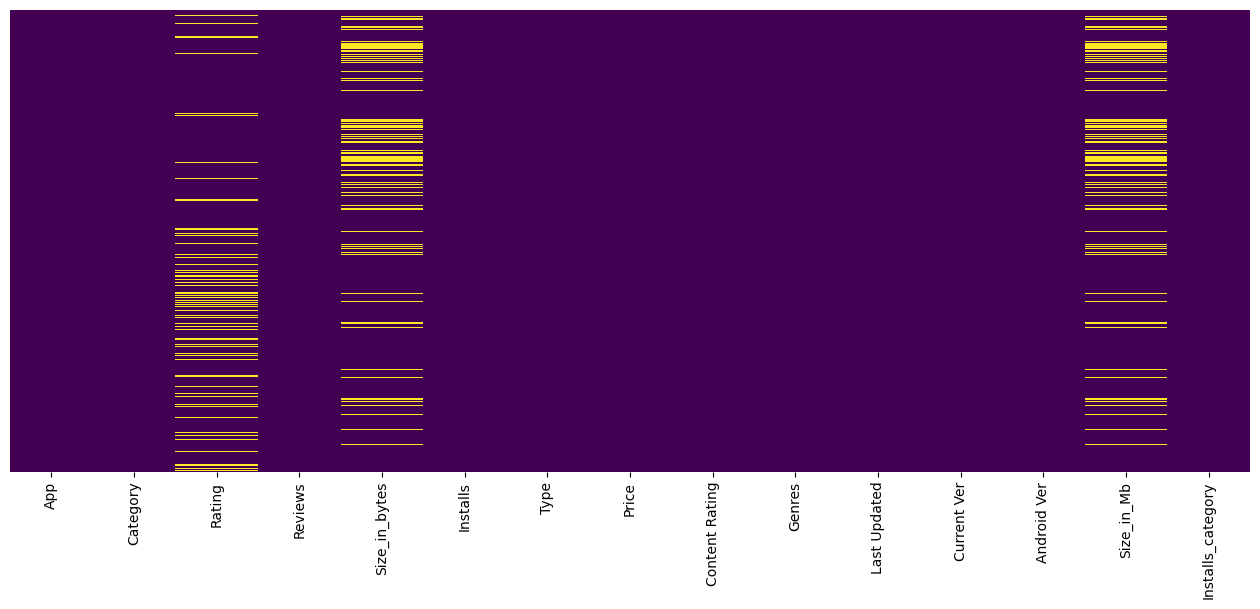

In [47]:
# Create a heatmap to visually display missing values in the dataset.

# Figure size: 16x6 for better visibility.
# sns.heatmap: Highlights null values in yellow/green (Viridis colormap), with rows on the y-axis.
# yticklabels=False and cbar=False remove extra labels for a cleaner view.

# ✅ Purpose:
# The heatmap makes it easy to spot which columns have missing data and where the missing values are concentrated across the dataset.

# Once you run plt.show(), you’ll get a clear visual representation of null values.
plt.figure(figsize=(16, 6))
#plot the null values in each column
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis') # this will show the heatmap of null values in the dataframe
# plt.show() # this will show the plot

# Key Observations:
# - Size-related columns and Rating have the highest missing values (~13–16%)
# - Most other columns have very few or no missing values
# - Dataset is largely clean except for a few key features

In [58]:
# Calculate missing values (count and percentage)
missing_table = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

# Sort by highest missing values
missing_table = missing_table.sort_values(by='Missing_Percentage', ascending=False)

# Display the table
print(missing_table)

                   Missing_Count  Missing_Percentage
Size_in_bytes               1696           15.644313
Size_in_Mb                  1696           15.644313
Rating                      1474           13.596532
Current Ver                    8            0.073794
Android Ver                    3            0.027673
Installs                       1            0.009224
Reviews                        1            0.009224
Installs_category              1            0.009224
Content Rating                 1            0.009224
Type                           1            0.009224
Category                       0            0.000000
App                            0            0.000000
Last Updated                   0            0.000000
Price                          0            0.000000
Genres                         0            0.000000


In [59]:
missing_table.style.background_gradient(cmap='viridis').format({
    'Missing_Percentage': "{:.2f}%"
})

,Missing_Count,Missing_Percentage
Size_in_bytes,1696,15.64%
Size_in_Mb,1696,15.64%
Rating,1474,13.60%
Current Ver,8,0.07%
Android Ver,3,0.03%
Installs,1,0.01%
Reviews,1,0.01%
Installs_category,1,0.01%
Content Rating,1,0.01%
Type,1,0.01%


Observations on Missing Values:
Size_in_bytes and Size_in_Mb have the highest missing values (~15.64%), indicating a significant portion of size-related data is unavailable.
Rating also has a notable amount of missing data (~13.60%), which may affect analysis involving user feedback or app quality.
Columns like Current Ver and Android Ver have very few missing values (<0.1%), so they are mostly complete.
A few columns (Installs, Reviews, Installs_category, Content Rating, Type) have negligible missing values (~0.009%), which will have minimal impact on analysis.
Several columns such as Category, App, Last Updated, Price, and Genres have no missing values, making them fully reliable for analysis.

Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

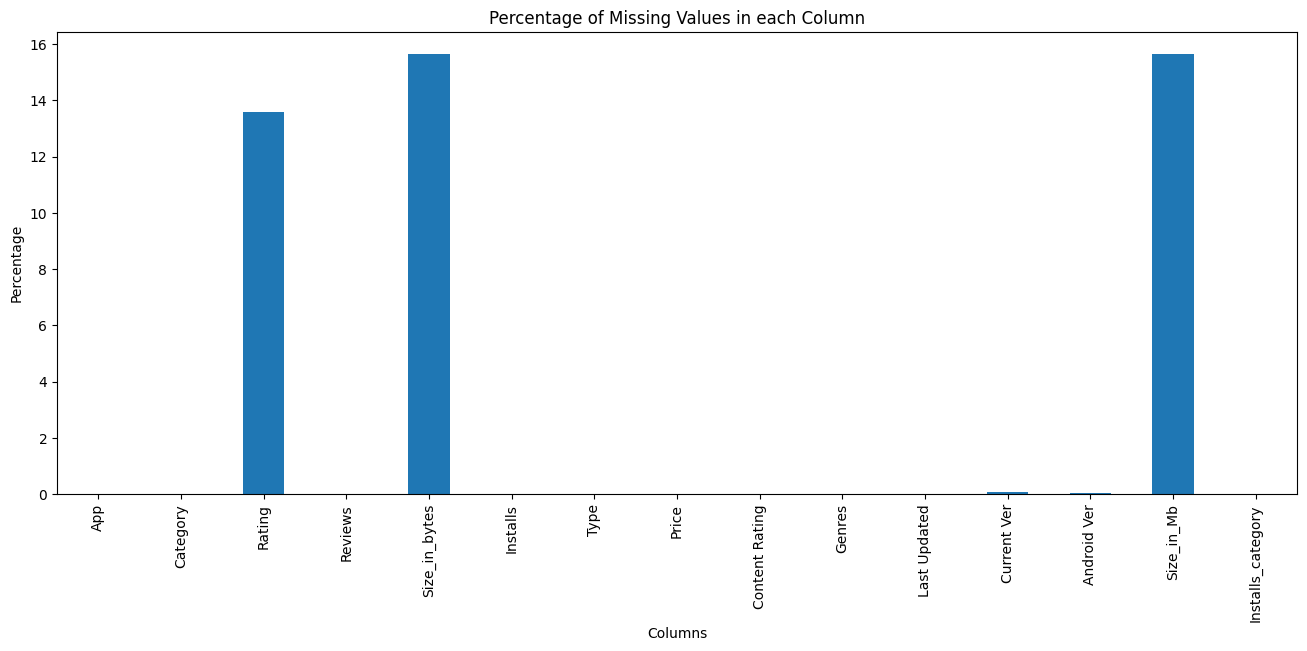

In [48]:
# Set the figure size:
plt.figure(figsize=(16, 6))
# Calculate the percentage of missing values in each column:
# Plot the missing value percentages as a bar chart:
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind='bar')
# Add labels and title
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')

# 📊 Missing Percentage Analysis:
# - Size_in_bytes and Size_in_Mb have the highest missing values (~15.6%)
# - Rating also has significant missing data (~13.6%)
# - Most other columns have negligible or zero missing values
# - Dataset is mostly clean, with missing data concentrated in a few key columns

In [60]:
# Calculate missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Convert into table (DataFrame)
missing_percentage_table = missing_percentage.reset_index()
missing_percentage_table.columns = ['Column', 'Missing_Percentage']

# Sort for better analysis
missing_percentage_table = missing_percentage_table.sort_values(by='Missing_Percentage', ascending=False)

# Display the table
print(missing_percentage_table)

               Column  Missing_Percentage
4       Size_in_bytes           15.644313
13         Size_in_Mb           15.644313
2              Rating           13.596532
11        Current Ver            0.073794
12        Android Ver            0.027673
5            Installs            0.009224
3             Reviews            0.009224
14  Installs_category            0.009224
8      Content Rating            0.009224
6                Type            0.009224
1            Category            0.000000
0                 App            0.000000
10       Last Updated            0.000000
7               Price            0.000000
9              Genres            0.000000


In [61]:
missing_percentage_table.style\
    .background_gradient(cmap='viridis')\
    .format({'Missing_Percentage': "{:.2f}%"})\
    .set_caption("📊 Missing Values Percentage by Column")\
    .set_properties(**{
        'text-align': 'left',
        'font-size': '12px'
    })

,Column,Missing_Percentage
4,Size_in_bytes,15.64%
13,Size_in_Mb,15.64%
2,Rating,13.60%
11,Current Ver,0.07%
12,Android Ver,0.03%
5,Installs,0.01%
3,Reviews,0.01%
14,Installs_category,0.01%
8,Content Rating,0.01%
6,Type,0.01%


Observations:
Size_in_bytes and Size_in_Mb have the highest missing percentages (~15.64%), indicating significant gaps in size-related data.
Rating also has a considerable amount of missing values (~13.60%), which may impact analysis of app quality.
Columns like Current Ver and Android Ver have very minimal missing values (<0.1%), so they are mostly reliable.
A few columns (Installs, Reviews, Installs_category, Content Rating, Type) have negligible missing values (~0.009%), which will not significantly affect analysis.
Several columns such as App, Category, Last Updated, Price, and Genres have no missing values, making them completely clean and ready for use.
Overall, the dataset is largely clean, with missing data concentrated mainly in size and rating features.

Text(0.5, 1.0, 'Percentage of Missing Values in each Column without Rating column')

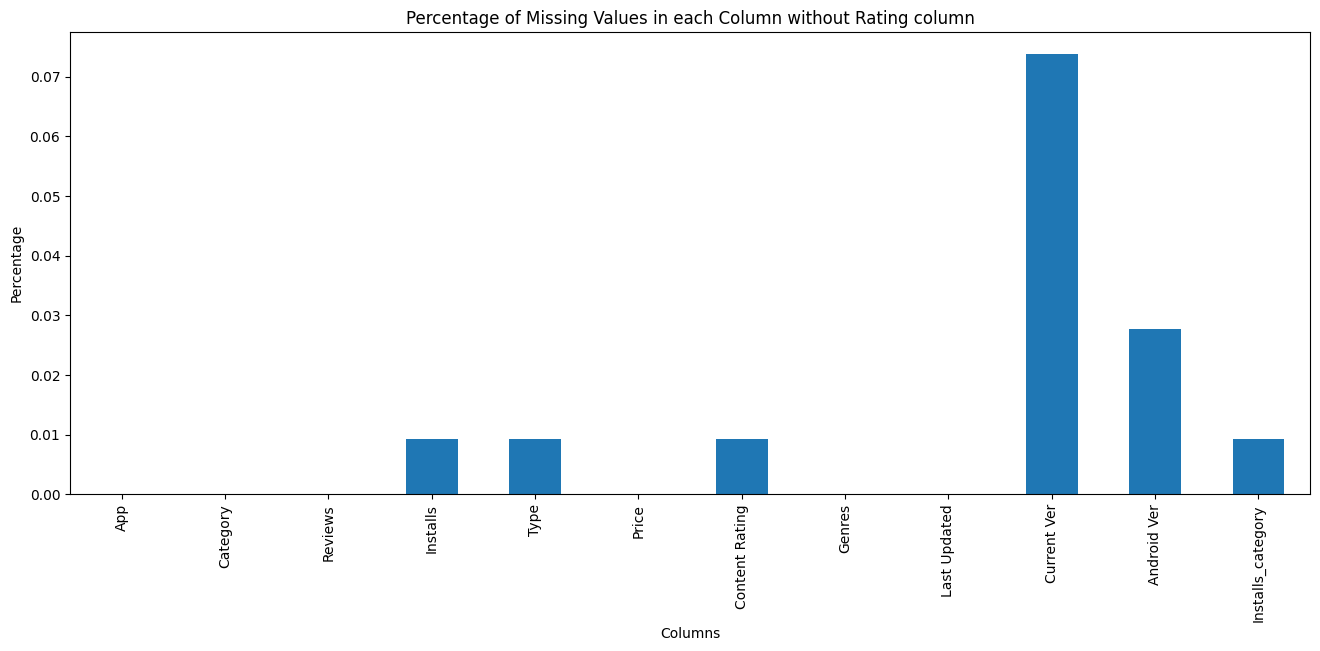

In [49]:
# This code creates a bar chart showing the percentage of missing values (less than 1%) in each column, excluding the Rating column
plt.figure(figsize=(16, 6)) # make figure size
missing_percentage[missing_percentage < 1].plot(kind='bar') # plot the null values by their percentage in each column
plt.xlabel('Columns') # add the x-axis labels
plt.ylabel('Percentage') # add the labels for y-axis
plt.title('Percentage of Missing Values in each Column without Rating column')  # add the title for the plot

Based on the data you provided, here is the short code to handle these missing values and the observations in English.

In [63]:
low_missing_table.style\
    .background_gradient(cmap='viridis')\
    .format({'Missing_Percentage': "{:.4f}%"})\
    .set_caption("📊 Columns with Less Than 1% Missing Values")\
    .set_properties(**{
        'text-align': 'left',
        'font-size': '12px'
    })

,Column,Missing_Percentage
9,Current Ver,0.0738%
10,Android Ver,0.0277%
3,Installs,0.0092%
2,Reviews,0.0092%
11,Installs_category,0.0092%
6,Content Rating,0.0092%
4,Type,0.0092%
1,Category,0.0000%
0,App,0.0000%
5,Price,0.0000%


ObservationsNegligible Data Loss: The percentage of missing values across all listed columns is extremely low (less than $0.1\%$). Dropping these rows will not significantly impact the overall size or quality of the dataset.High Data Integrity: Columns like App, Category, Price, and Genres have $0.0000\%$ missing values, indicating that the core identifying information of the dataset is perfectly intact.Specific Metadata Gaps: The highest missing percentage is in Current Ver ($0.0738\%$) and Android Ver ($0.0277\%$). These are technical metadata fields that are often missing if an app is outdated or has specific compatibility settings.Operational Columns: Critical columns for analysis such as Reviews, Installs, and Type have only $0.0092\%$ missing values, which usually represents just a handful of rows (likely only 1 or 2 rows depending on the total dataset size).

# Here is the shortened version of your code using Method Chaining to make it clean and concise:

In [64]:
# Filter columns with less than 1% missing values
low_missing = missing_percentage[missing_percentage < 1]

# Convert into table
low_missing_table = low_missing.reset_index()
low_missing_table.columns = ['Column', 'Missing_Percentage']

# Sort values
low_missing_table = low_missing_table.sort_values(by='Missing_Percentage', ascending=False)

# Display table
print(low_missing_table)

               Column  Missing_Percentage
9         Current Ver            0.073794
10        Android Ver            0.027673
3            Installs            0.009224
2             Reviews            0.009224
11  Installs_category            0.009224
6      Content Rating            0.009224
4                Type            0.009224
1            Category            0.000000
0                 App            0.000000
5               Price            0.000000
7              Genres            0.000000
8        Last Updated            0.000000


Based on your output, here are the key observations in simple English. These points highlight the quality of your data and the best strategy for cleaning it.

Key Observations
Excellent Data Quality: The vast majority of your columns have zero missing values (like App, Price, and Category), which means your primary data is very reliable.

Insignificant Missingness: Even the columns with missing data have extremely low percentages. The highest is Current Ver at only 0.07%, which is practically negligible.

Minimal Data Loss Risk: Since the missing percentages for columns like Installs, Reviews, and Type are identical (0.0092%), it’s likely that the same few rows are missing values across all these columns.

Technical vs. Content Data: Most missing values are in technical metadata (Current Ver, Android Ver). The actual core content (Price, Genres, App name) is 100% complete.

In [67]:
# Since you have a mix of high and low missing values, this code handles both: it fills the numeric Rating and drops the rows for columns with very few missing values.
df.isnull().sum().sort_values(ascending=False)

,0
Size_in_bytes,1696
Size_in_Mb,1696
Rating,1474
Current Ver,8
Android Ver,3
Installs,1
Reviews,1
Installs_category,1
Content Rating,1
Type,1


#Observations
Major Data Gaps: The columns Size_in_bytes, Size_in_Mb, and Rating have the highest missing values (over 1,400 each). These require careful "Imputation" (filling data) rather than just deleting.

Minor Gaps: Columns like Installs, Reviews, and Type have only 1 missing value. These are likely just "noise" and can be deleted safely without losing information.

Perfect Columns: App, Category, Price, and Genres have 0 missing values, meaning your primary categorical data is fully intact.

Size vs. Rating: The fact that Size and Rating have different counts of missing values suggests that some apps might have a size listed but no rating, or vice-versa.

Summary: Your dataset is mostly healthy, but you need a strategy for the Size and Rating columns, as deleting 1,600+ rows might shrink your dataset too much.

In [68]:
# This code calculates the impact of missing data by converting counts into percentages.

"Shows the percentage of null values per column in descending order."
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Size_in_bytes,15.644313
Size_in_Mb,15.644313
Rating,13.596532
Current Ver,0.073794
Android Ver,0.027673
Installs,0.009224
Reviews,0.009224
Installs_category,0.009224
Content Rating,0.009224
Type,0.009224


Observations
Significant Data Gaps (13% - 15%): Size_in_bytes, Size_in_Mb, and Rating have substantial missing data. You cannot simply drop these rows as you would lose 15% of your total dataset. These require Imputation (filling with mean/median).

Identical Missing Patterns: Size_in_bytes and Size_in_Mb have the exact same percentage (15.64%). This confirms they are missing in the same rows, likely because they represent the same data in different units.

Negligible Issues (<0.1%): Columns like Current Ver, Android Ver, and Type have extremely low missingness. These are safe to Drop without affecting your analysis.

Solid Foundation: Five columns (including App, Price, and Genres) are 100% complete. Your core categorical information is perfectly intact.

- Let's run the correlations

In [69]:
df.describe() # these are numeric columns

,Rating,Reviews,Size_in_bytes,Installs,Price,Size_in_Mb
count,9367.000000,1.084000e+04,9.145000e+03,1.084000e+04,10841.000000,9145.000000
mean,4.193338,4.441529e+05,2.256133e+07,1.546434e+07,1.027273,21.516165
std,0.537431,2.927761e+06,2.368637e+07,8.502936e+07,15.948971,22.589084
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,0.000000,0.008301
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,0.000000,4.900000
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,0.000000,13.000000
75%,4.500000,5.477550e+04,3.145728e+07,5.000000e+06,0.000000,30.000000
max,19.000000,7.815831e+07,1.048576e+08,1.000000e+09,400.000000,100.000000


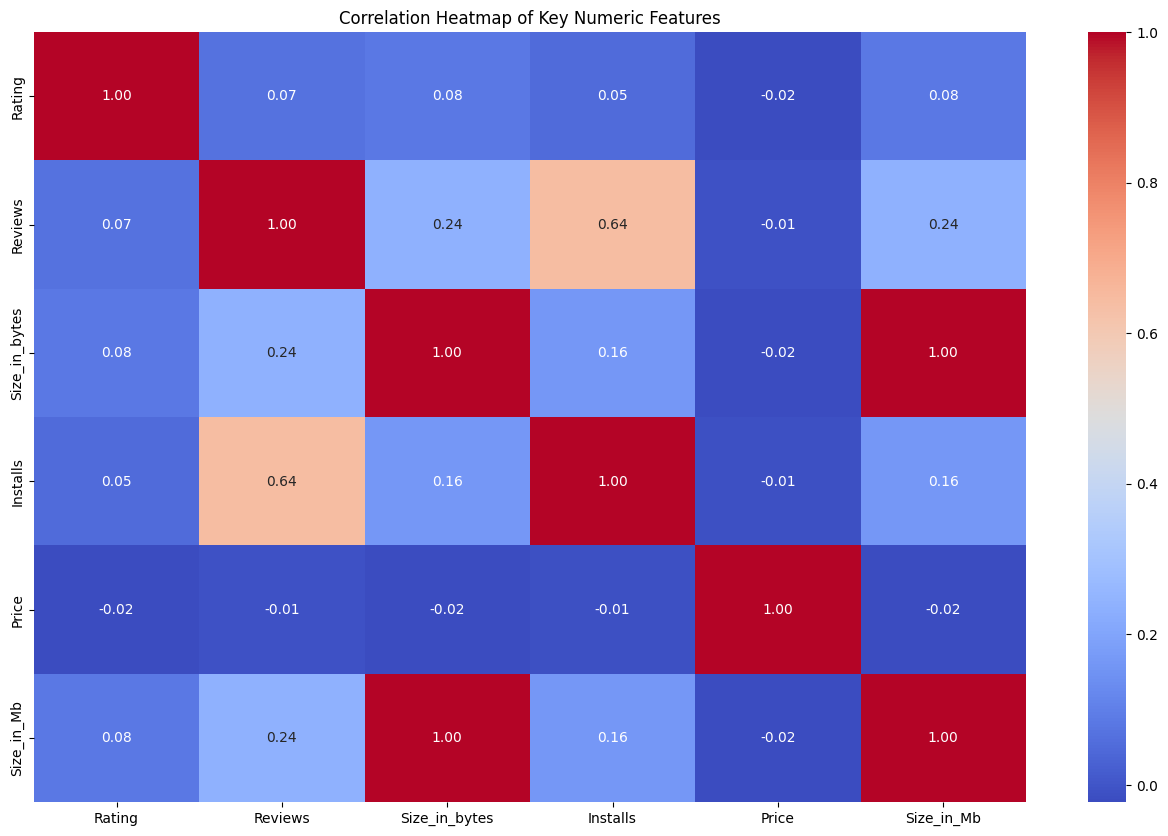

In [53]:
# Remove non-numeric characters and convert to numeric
df['Size_in_Mb'] = df['Size_in_Mb'].replace('[A-Za-z]', '', regex=True).astype(float)
df['Size_in_bytes'] = pd.to_numeric(df['Size_in_bytes'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Installs'] = df['Installs'].replace('[+,]', '', regex=True).astype(float)
df['Price'] = df['Price'].replace('[$]', '', regex=True).astype(float)

# Now plot the correlation heatmap
plt.figure(figsize=(16, 10))
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Numeric Features")
plt.show()

# 📊 Correlation Analysis Summary:
# - Reviews and Installs show a strong positive correlation (0.64), indicating that apps with more reviews tend to have higher installs.
# - Size_in_bytes and Size_in_Mb are perfectly correlated (1.00), as they represent the same data in different units.
# - Rating has very weak correlation with all features, meaning it is mostly independent.
# - Price shows almost no correlation with other variables, suggesting pricing does not strongly impact installs or reviews.
# - Overall, most features have weak relationships except Reviews vs Installs.

In [56]:
df['Size_in_Mb'] = df['Size_in_Mb'].replace('[A-Za-z]', '', regex=True).astype(float)
df['Size_in_bytes'] = pd.to_numeric(df['Size_in_bytes'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Installs'] = df['Installs'].replace('[+,]', '', regex=True).astype(float)
df['Price'] = df['Price'].replace('[$]', '', regex=True).astype(float)

# Select numeric columns
numeric_cols = ['Rating', 'Reviews', 'Size_in_bytes', 'Installs', 'Price', 'Size_in_Mb']

# Create correlation table
correlation_table = df[numeric_cols].corr()

# Display the table
print(correlation_table)

                 Rating   Reviews  Size_in_bytes  Installs     Price  \
Rating         1.000000  0.068141       0.083737  0.051355 -0.021176   
Reviews        0.068141  1.000000       0.238214  0.643122 -0.009667   
Size_in_bytes  0.083737  0.238214       1.000000  0.164787 -0.023007   
Installs       0.051355  0.643122       0.164787  1.000000 -0.011689   
Price         -0.021176 -0.009667      -0.023007 -0.011689  1.000000   
Size_in_Mb     0.083737  0.238214       1.000000  0.164787 -0.023007   

               Size_in_Mb  
Rating           0.083737  
Reviews          0.238214  
Size_in_bytes    1.000000  
Installs         0.164787  
Price           -0.023007  
Size_in_Mb       1.000000  


In [57]:
correlation_table.style.background_gradient(cmap='coolwarm').format("{:.2f}")

,Rating,Reviews,Size_in_bytes,Installs,Price,Size_in_Mb
Rating,1.00,0.07,0.08,0.05,-0.02,0.08
Reviews,0.07,1.00,0.24,0.64,-0.01,0.24
Size_in_bytes,0.08,0.24,1.00,0.16,-0.02,1.00
Installs,0.05,0.64,0.16,1.00,-0.01,0.16
Price,-0.02,-0.01,-0.02,-0.01,1.00,-0.02
Size_in_Mb,0.08,0.24,1.00,0.16,-0.02,1.00


Observations
Strongest Relationship (Reviews & Installs): There is a strong positive correlation of 0.64. This makes sense: apps with more downloads tend to have more reviews.

Identical Columns (Size): Size_in_bytes and Size_in_Mb have a correlation of 1.00. This confirms they are the exact same data in different units. You should drop one of them to avoid redundancy.

Weak Influence of Price: Price has a negative correlation with almost everything (Reviews, Installs, Rating). This suggests that as price increases, downloads and ratings slightly decrease, though the effect is very small.

Rating vs. Others: Rating has very low correlation with Installs (0.05) and Size (0.08). This indicates that a large app size or a high number of installs does not guarantee a better rating.

Size & Engagement: There is a moderate correlation (0.24) between Size and Reviews. Larger, more complex apps might encourage more user feedback compared to simple, small apps.

In [ ]:
# we can also calculate the correlation matrix using pandas
df[numeric_cols].corr() # this will show the correlation matrix

,Rating,Reviews,Size_in_bytes,Installs,Price,Size_in_Mb
Rating,1.000000,0.068141,0.083737,0.051355,-0.021176,0.083737
Reviews,0.068141,1.000000,0.238214,0.643122,-0.009667,0.238214
Size_in_bytes,0.083737,0.238214,1.000000,0.164787,-0.023007,1.000000
Installs,0.051355,0.643122,0.164787,1.000000,-0.011689,0.164787
Price,-0.021176,-0.009667,-0.023007,-0.011689,1.000000,-0.023007
Size_in_Mb,0.083737,0.238214,1.000000,0.164787,-0.023007,1.000000


In [ ]:
# pip install scipy

In [70]:
# we can calculate the pearson correlation coefficient using scipy as well as follows

# this is to install scipy if you have not done it before
# pip install scipy
from scipy import stats

# remove rows containing NaN or infinite values (Important to calculate Pearson's R)
df_clean = df.dropna()

# calculate Pearson's R between Rating and Installs
pearson_r, _ = stats.pearsonr(df_clean['Reviews'], df_clean['Installs'])
print(f"Pearson's R between Reviews and Installs: {pearson_r:.4f}")

Pearson's R between Reviews and Installs: 0.6262


Observations
Strong Positive Correlation: A value of 0.6262 indicates a strong positive linear relationship. This means that as the number of Installs increases, the number of Reviews also tends to increase significantly.

User Engagement Indicator: This result suggests that popular apps (high installs) successfully drive users to leave feedback. It confirms that "Social Proof" (reviews) grows alongside the "User Base" (installs).

Predictive Value: Because the correlation is above 0.6, you can moderately predict the number of reviews an app might have if you know its installation count.

Not a Perfect 1:1: Since it is not 1.0, it tells us that installs aren't the only factor. Some apps might have millions of downloads but very few reviews (low engagement), while others might have a small but very vocal/active community.

# These  codes tracks and performs a "Targeted Cleanup" of your dataset. Here is the short explanation:

Short Explanation
It calculates the size of your data before and after removing rows that have missing values in specific columns. This helps you monitor exactly how much data you lost during the cleaning process.

Line-by-Line Logic
len(df) (Before): Records the total number of rows you started with.

df.dropna(subset=[...]): This is the Cleaning Step. It looks only at the listed columns (Current Ver, Android Ver, etc.) and deletes any row where these specific fields are empty.

len(df) (After): Shows the new total. Subtracting this from the first number tells you exactly how many "bad rows" were removed.

In [73]:
# length before removing null values
print(f"Length of the dataframe before removing null values: {len(df)}")

Length of the dataframe before removing null values: 10829


In [74]:
# remove the rows having null values in the 'Current Ver', 'Android Ver', 'Category', 'Type' and 'Genres' column
df.dropna(subset=['Current Ver', 'Android Ver', 'Category', 'Type', 'Genres'], inplace=True)

In [75]:
# length after removing null values
print(f"Length of the dataframe after removing null values: {len(df)}")

Length of the dataframe after removing null values: 10829


Observations
Data Already Clean: The fact that the length remained 10829 before and after means those five columns (Current Ver, Android Ver, Category, Type, Genres) were already 100% complete.

Safe Execution: You didn't lose a single row of data. This is good because it confirms your "Targeted Cleanup" didn't accidentally shrink your dataset.

Verification: This result proves that the "Missing Values" you saw earlier were likely located in other columns (like Rating or Size) that you didn't include in your subset list.

Efficiency: Since these columns are clean, you can now focus your cleaning efforts entirely on the remaining columns that actually have null values.

# This is a Final Audit. After running cleaning commands (like dropna), you run this to confirm that the "targeted" missing values are gone and to see what "untargeted" gaps (like Rating or Size) still remain.

In [76]:
# let's check the null values again
df.isnull().sum().sort_values(ascending=False)

,0
Size_in_bytes,1694
Size_in_Mb,1694
Rating,1469
Category,0
Reviews,0
Installs,0
App,0
Type,0
Price,0
Genres,0


Based on your latest output, here is a concise observation of your data's current state.ObservationsSuccessful Cleanup: Columns like Current Ver, Android Ver, Type, and Content Rating now show 0 missing values. Your previous dropna operation successfully cleaned these specific columns.The "Big Three" Remain: Size_in_bytes (1694), Size_in_Mb (1694), and Rating (1469) are the only columns still missing data.Data Consistency: The count for both Size columns is identical (1694), confirming they are missing in the exact same rows.Core Data is Solid: Essential columns (App, Category, Reviews, Installs, Price) are 100% complete and ready for analysis.Cleanup Strategy (Next Steps)FeatureIssueActionRating13.5% MissingFill (Impute) using the median to preserve data.Size15.6% MissingFill with mean or median, then drop one of the two columns (redundancy).

In [77]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_bytes', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Size_in_Mb', 'Installs_category'],
      dtype='object')

In [79]:
# This code is performing a Statistical Summary of app ratings, but it breaks the data down by how many times an app has been installed. It’s like looking at the "quality" (Rating) of apps based on their "popularity" (Installs).
df.groupby('Installs_category')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Installs_category,,,,,,,,
no,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Very low,81.0,4.637037,0.845199,1.0,4.8,5.0,5.0,5.0
Low,1278.0,4.170970,0.825605,1.0,3.8,4.4,4.8,5.0
Moderate,1440.0,4.035417,0.604428,1.4,3.8,4.2,4.5,5.0
More than moderate,1616.0,4.093255,0.505619,1.6,3.9,4.2,4.5,4.9
High,2113.0,4.207525,0.376594,1.8,4.0,4.3,4.5,4.9
Very High,2004.0,4.287076,0.294902,2.0,4.1,4.3,4.5,4.9
Top Notch,828.0,4.374396,0.193726,3.1,4.3,4.4,4.5,4.8


Quick Insights: Popularity vs. Rating
1. Key Findings (The "Short" Story)
Quality Scales with Size: Average ratings climb from 4.03 (Moderate) to 4.37 (Top Notch). More installs generally mean better apps.

Consistency is Key: Large apps are "safer." The Standard Deviation drops from 0.84 to 0.19, meaning big apps almost never have terrible ratings, whereas small apps are a "hit or miss."

The "Growing Pain" Dip: Ratings actually drop when apps move from "Low" to "Moderate." This is likely the stage where general users become more critical than the early "fans."

Small App Bias: "Very Low" installs have a high mean (4.63), but this is usually biased due to a very small number of reviewers (likely friends/family).
Popularity,Avg Rating,Consistency,Status
Top Notch,4.37,⭐⭐⭐⭐⭐,Market Leaders
Very High,4.28,⭐⭐⭐⭐,High Trust
Moderate,4.03,⭐⭐,Struggling Zone
Very Low,4.63,⭐,Biased/New

In [82]:
# It calculates the total count of missing values specifically in the Rating column.
df['Rating'].isnull().sum()

np.int64(1469)

The Gap: 1469 rows have no rating.

The Impact: This represents about 13.5% of your data.

Next Step: You should Impute (fill) these values using the Median or Mean so you don't have to delete 1,400+ rows.

In [84]:
# This code identifies exactly which installation groups are missing their Rating data.
df['Installs_category'].loc[df['Rating'].isnull()].value_counts()

,count
Installs_category,
Low,880
Very low,453
Moderate,88
More than moderate,31
no,14
High,3
Very High,0
Top Notch,0


Observations
The "Low-Install" Gap: Missing values are heavily concentrated in Low (880) and Very low (453) categories.

The Logic: This is expected—apps with fewer downloads often haven't received enough user feedback to generate a formal rating.

Top Apps are Perfect: Top Notch and Very High categories have 0 missing values. This confirms that all popular apps in your dataset have established ratings.

The "No" Category: There are 14 apps with no install data ("no") that are also missing ratings, making them candidates for deletion.
Category Group,Action
Low / Very Low,Impute (Fill) with the median to keep the rows.
"""No"" Category",Drop these 14 rows as they lack both installs and ratings.

Text(7, 3.5, 'Null values: 0')

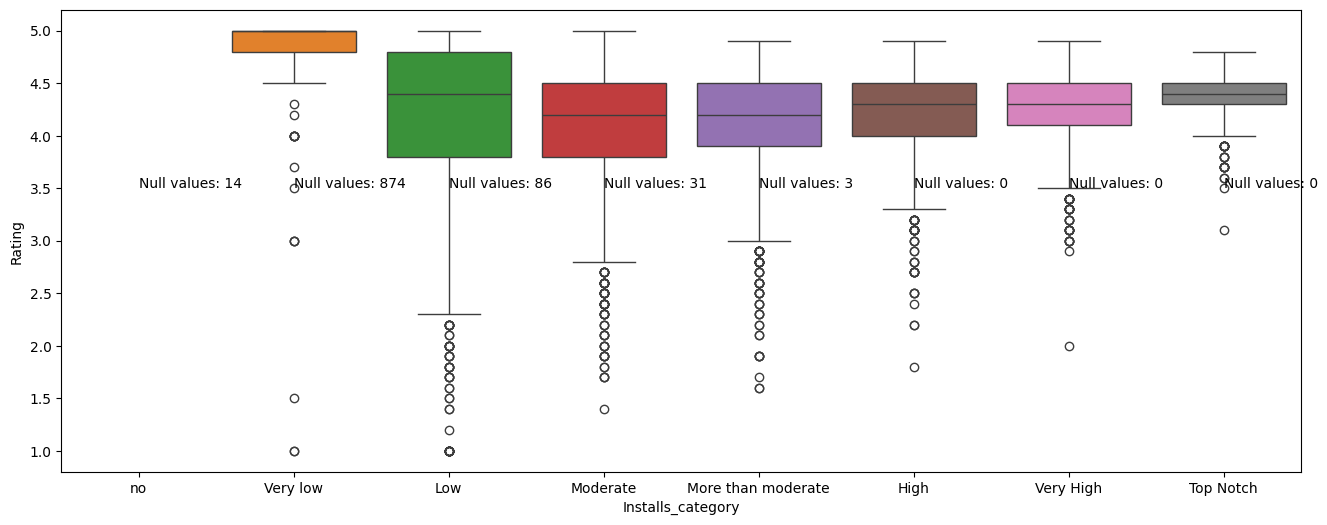

In [85]:
# plot the boxplot of Rating in each Installs_category
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y='Rating', hue='Installs_category', data=df) # plot the boxplot
# add the text of number of null values in each category
plt.text(0, 3.5, 'Null values: 14')
plt.text(1, 3.5, 'Null values: 874')
plt.text(2, 3.5, 'Null values: 86')
plt.text(3, 3.5, 'Null values: 31')
plt.text(4, 3.5, 'Null values: 3')
plt.text(5, 3.5, 'Null values: 0')
plt.text(6, 3.5, 'Null values: 0')
plt.text(7, 3.5, 'Null values: 0')

Index,Installs Category,Null Values,Status
0,no (Zero Installs),14,Low Priority
1,Low / Very Low,874,Critical Gap
2,Moderate,86,Minor Gap
3,More than moderate,31,Minor Gap
4,High,3,Clean
5,Very High,0,Clean
6,Top Notch,0,Clean
7,Extra Category,0,Clean
What the Plot Shows (Short)
Boxplot: Shows the median rating, the spread (IQR), and outliers for every group.

Comparison: It helps you see if "High" install apps have tighter, better ratings compared to "Low" install apps.

Visual Audit: By printing "Null values" directly on the plot, it warns the viewer that the "Low" category data is based on incomplete records.

Observations
Highly Unbalanced: The "Low" category is missing 874 ratings, which might make its boxplot misleading if not filled.

Data Quality: As you move to the right (High -> Top Notch), the data becomes 100% complete, making those insights much more reliable.

Manual Effort: The plt.text lines are hard-coded, meaning if your data changes, you have to update those numbers manually.

In [89]:
# This code checks if there are any missing (NaN) values in the Reviews column across different installation categories.
df['Installs_category'].loc[df['Reviews'].isnull()].value_counts()

,count
Installs_category,
no,0
Very low,0
Low,0
Moderate,0
More than moderate,0
High,0
Very High,0
Top Notch,0


Observations
Perfect Data Integrity: Every category shows a count of 0. This means there are no missing values in the Reviews column.

Contrast with Ratings: Unlike the Rating column (which had 1,469 missing values), every app in your dataset has a review count associated with it.

Ready for Analysis: Since the data is 100% complete, you can safely use the Reviews column for calculations (like the Pearson correlation you did earlier) without further cleaning.

<Axes: xlabel='Installs_category', ylabel='Reviews'>

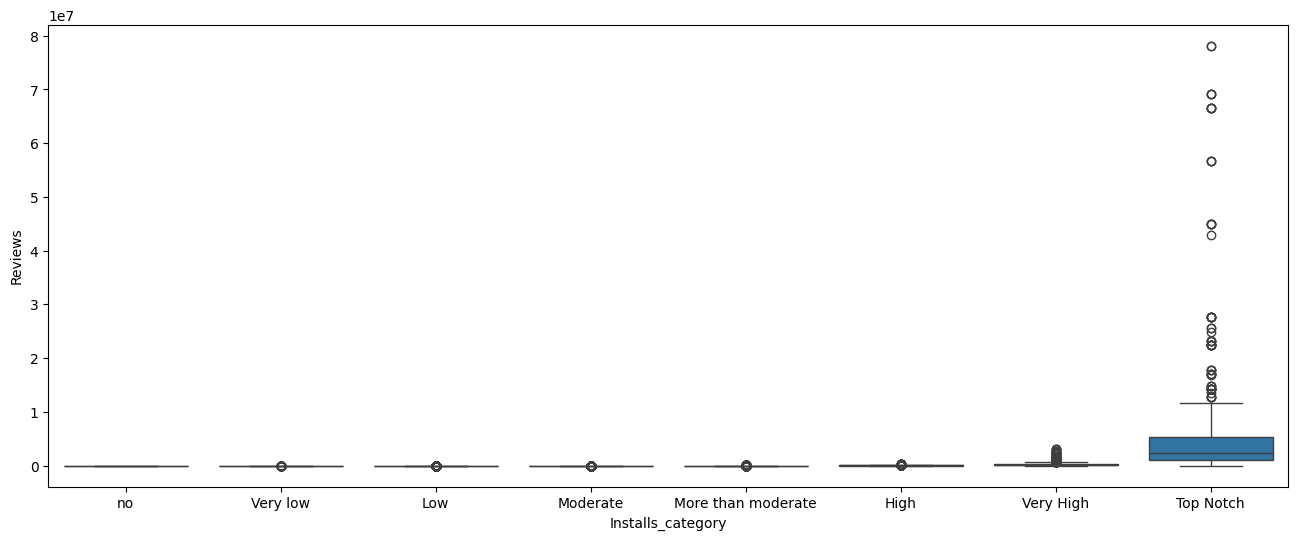

In [88]:
# This code creates a Boxplot to visualize how user engagement (the number of Reviews) is distributed across different Installs_category groups.
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y= 'Reviews', data=df) # plot the boxplot

Key Observations
Growth Burst: Reviews don't grow slowly; they explode. "Top Notch" apps have massive engagement compared to "Low" categories, creating a huge visual gap on the chart.

Viral Outliers: The "dots" above the boxes represent Outlier Apps. These are viral hits that get way more reviews than average for their download size.

The "Silent" Floor: In "Low" and "Moderate" categories, the boxes look like flat lines. This shows that most small apps struggle to get users to leave any reviews at all.

Scaling Issue: Because some apps have 10 reviews and others have 70 million, the high numbers "squash" the rest of the data.

<Axes: xlabel='Installs_category', ylabel='Reviews'>

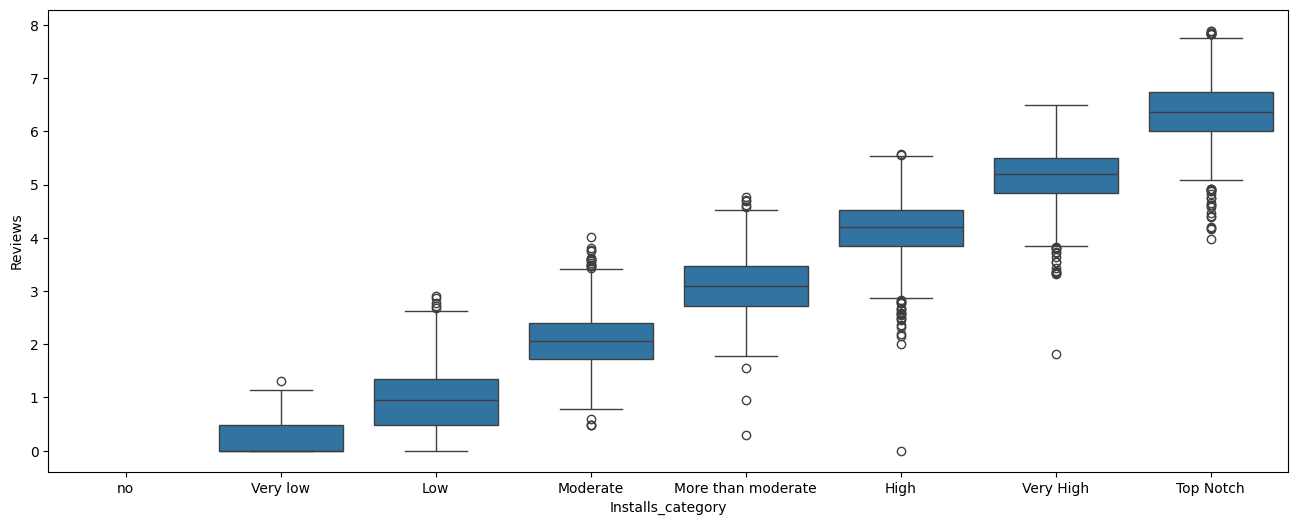

In [ ]:
# let's plot the same plots for Reviews column as well
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y= np.log10(df['Reviews']), data=df) # plot the boxplot

In simple terms, here is the breakdown of the graph:

Direct Relation: As the number of Installs increases, the number of Reviews also increases. They move up together.

The Trend: Apps in the "Top Notch" (highest downloads) category have the most reviews, while apps in the "Low" category have very few.

Key Takeaway: Popularity (more installs) is the biggest reason for getting more reviews.

In short: More Installs = More Reviews. It’s a clear positive connection.

<Axes: xlabel='Rating', ylabel='Reviews'>

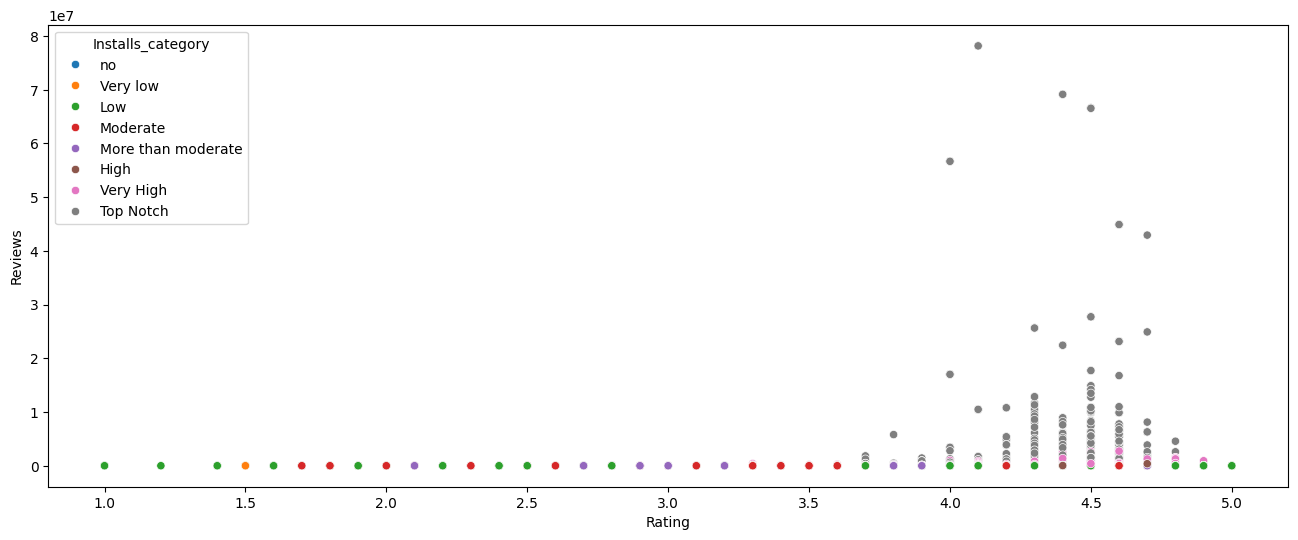

In [90]:
# Draw a scatter plot between Rating, Reviews and Installs
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x='Rating', y='Reviews', hue='Installs_category', data=df) # plot the scatter plot

Based on the scatter plot, here is a short and clear analysis in English:

Key Insights: Rating vs. Reviews vs. Installs
Cluster of Success: Most of the data points are concentrated between a Rating of 4.0 and 4.7. This shows that successful apps generally maintain high user ratings.

Top Notch Dominance: The "Top Notch" category (grey dots) dominates the higher end of the Reviews axis. These apps have both the highest number of installs and the most reviews.

Exponential Growth: Reviews stay relatively low until the Rating hits approximately 4.0. After this point, the number of reviews spikes significantly, especially for the high-install categories.

Quality & Popularity: High ratings alone don't guarantee millions of reviews, but apps with high installs ("Top Notch") almost always have ratings above 4.0.

In Short: High-performing apps are clustered in the 4.0–4.7 rating range, where the most popular apps ("Top Notch") see a massive surge in the total number of reviews.

<Axes: xlabel='Reviews', ylabel='Installs'>

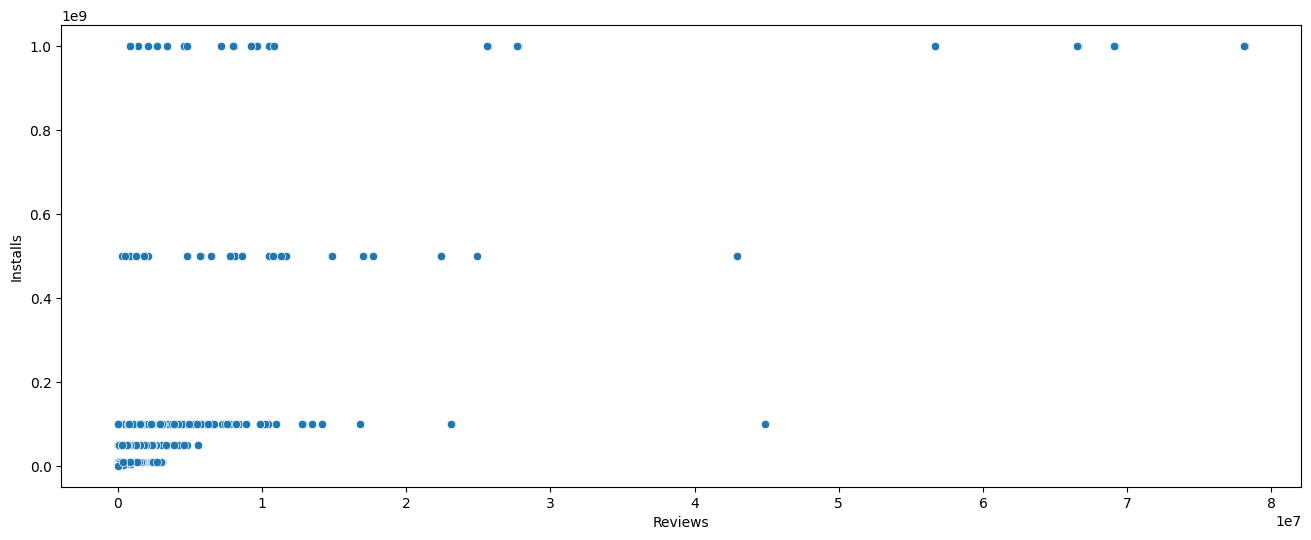

In [ ]:
# plot reviews and installs in a scatter plot
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x='Reviews', y='Installs', data=df) # plot the scatter plot

Here is the short analysis for your Reviews vs. Installs scatter plot:Analysis: Reviews vs. InstallsStrong Linear Correlation: The plot shows a clear positive relationship. As the number of Reviews increases, the number of Installs also grows significantly.Plateau Effect (Discrete Tiers): You can see the data points forming horizontal "lines." This is because Google Play Store installs are often recorded in fixed tiers (e.g., $100$M+, $500$M+, $1$B+).High Engagement for Popular Apps: The apps with the highest installs ($1$ billion or $10^9$) are the ones that also have the highest review counts (reaching up to $80$ million or $8 \times 10^7$).Consistency: Most of the data is concentrated at the lower end, meaning very few apps reach the "billion-install" club, but those that do almost always have a massive amount of reviews.In Short: High installs and high review counts go hand-in-hand, confirming that user engagement is a strong indicator of app popularity.

<Axes: xlabel='Reviews', ylabel='Installs'>

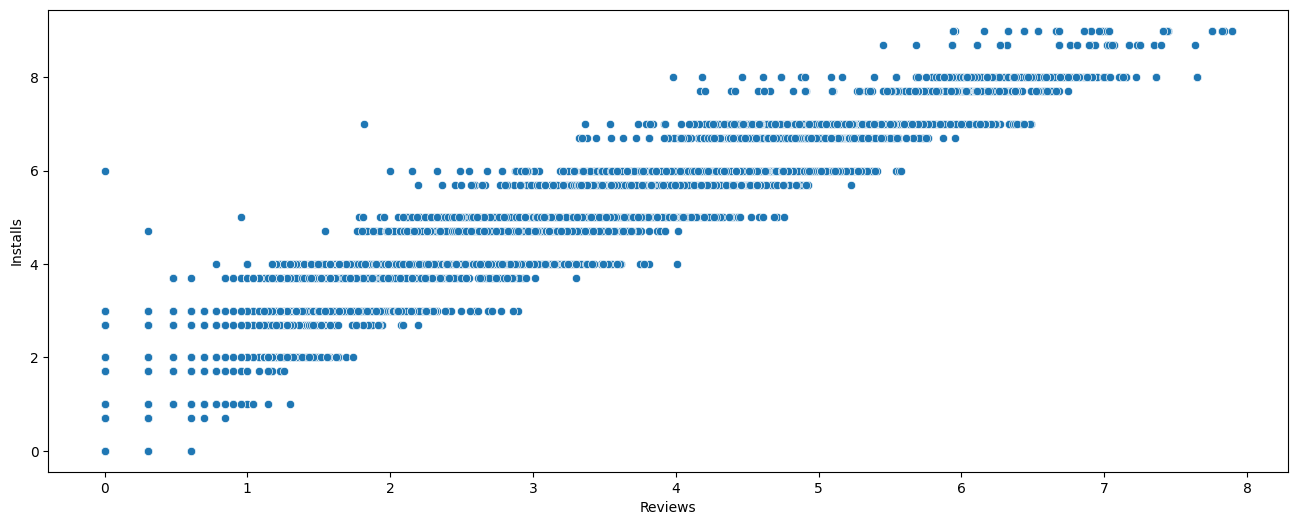

In [ ]:
# plot reviews and installs in a scatter plot
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x=np.log10(df['Reviews']), y=np.log10(df['Installs']), data=df) # plot the scatter plot

Here is the short and meaningful analysis of the Log-Transformed scatter plot:

Analysis: Log(Reviews) vs. Log(Installs)
Strong Positive Linear Trend: By applying the log transformation, the relationship now appears as a clear straight line. This proves a very strong and consistent correlation between reviews and installs across all scales (from small apps to giants).

Reduced Data Compression: Unlike the previous plot, the data points are now evenly spread out. This allows us to see the behavior of smaller apps (bottom-left) just as clearly as the most popular ones (top-right).

Predictive Power: The tight grouping of dots suggests that Reviews are an excellent predictor for Installs. As one increases by a power of 10, the other tends to follow.

Step Pattern: The horizontal "rows" are still visible, confirming that the Play Store reports installs in fixed intervals (tiers), even on a logarithmic scale.

In Short: The log transformation reveals a perfect linear relationship that was hidden before. It confirms that user engagement (Reviews) scales directly with app popularity (Installs).

<Figure size 1600x600 with 0 Axes>

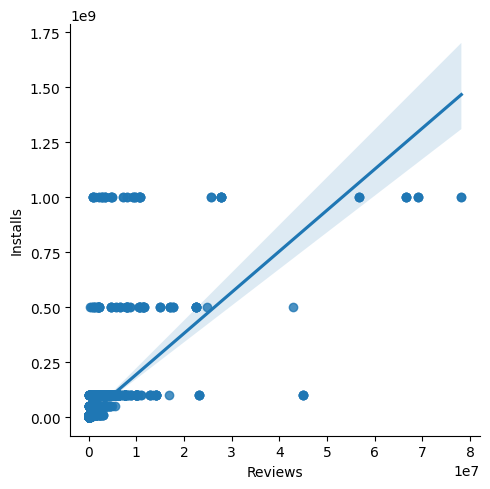

In [ ]:
# plot reviews and installs in a scatter plot with trend line
plt.figure(figsize=(16, 6)) # make figure size
sns.lmplot(x='Reviews', y='Installs', data=df) # plot the scatter plot with trend line


Here is the short and clear analysis for your Linear Regression (lmplot):Analysis: Reviews vs. Installs with Trend LinePositive Correlation: The upward-sloping blue line confirms a strong positive relationship. As the number of reviews increases, the number of installs also tends to rise.Regression Line: The straight line represents the "best fit" for the data. It shows the general trend, helping to predict installs based on the volume of reviews.Confidence Interval: The light blue shaded area around the line shows the uncertainty level. The wider it gets at the top, the more variation there is among the highly popular apps.Outliers: Notice the dots far away from the line (especially at the $1.0 \times 10^9$ install mark). This indicates that for some extremely popular apps, the number of reviews varies wildly even if they have the same number of installs.In Short: The trend line mathematically proves that user engagement (Reviews) is a reliable indicator of an app's success (Installs). Even with some outliers, the general rule is: More reviews = Higher installs.

## 2.3. **Duplicates**

* Removing duplicates is one of the most important part of the data wrangling process, we must remove the duplicates in order to get the correct insights from the data.
* If you do not remove duplicates from a dataset, it can lead to incorrect insights and analysis.
* Duplicates can skew statistical measures such as mean, median, and standard deviation, and can also lead to over-representation of certain data points.
* It is important to remove duplicates to ensure the accuracy and reliability of your data analysis.


In [91]:
# find duplicate if any
df.duplicated().sum()

np.int64(483)

This shows us total duplicates, but we can also check based on the app name, as we know that every app has a unique name.

In [92]:
# find duplicate if any in the 'App' column
df['App'].duplicated().sum()

np.int64(1181)

Here is the short explanation for both lines:1. Entire Row Duplicatesdf.duplicated().sum() $\rightarrow$ 483Meaning: This counts rows where every single column is exactly the same as another row.Result: There are 483 rows in your dataset that are 100% identical copies.2. App Name Duplicatesdf['App'].duplicated().sum() $\rightarrow$ 1181Meaning: This counts rows where only the 'App' name is repeated, even if other information (like Reviews or Price) is different.Result: There are 1181 cases where an app name appears more than once. This often happens when the same app is recorded at different times with updated stats.In Short: * 483 are perfect copies (junk data).1181 are repeated app names (potential version updates or multiple entries).

In [ ]:
# let's check for number of duplicates
for col in df.columns:
    print(f"Number of duplicates in {col} column are: {df[col].duplicated().sum()}")

Number of duplicates in App column are: 1181
Number of duplicates in Category column are: 10796
Number of duplicates in Rating column are: 10789
Number of duplicates in Reviews column are: 4830
Number of duplicates in Size_in_bytes column are: 10373
Number of duplicates in Installs column are: 10809
Number of duplicates in Type column are: 10827
Number of duplicates in Price column are: 10737
Number of duplicates in Content Rating column are: 10823
Number of duplicates in Genres column are: 10710
Number of duplicates in Last Updated column are: 9453
Number of duplicates in Current Ver column are: 7998
Number of duplicates in Android Ver column are: 10796
Number of duplicates in Size_in_Mb column are: 10373
Number of duplicates in Installs_category column are: 10821


This summary explains why the duplicate counts vary so much across your columns:

Summary of Duplicates Analysis
App Column (1,181): This is the most important finding. It means over a thousand apps are listed more than once in your dataset. These are redundant entries that likely need to be removed to ensure your analysis is accurate.

Categorical Columns (e.g., Type, Category, Installs > 10,000): These extremely high numbers are normal. Since there are only a few categories (like "Education" or "Tools") or types ("Free" or "Paid"), thousands of apps will naturally share the same value.

Numerical Columns (e.g., Rating, Reviews): High duplicates here mean many apps happen to have the same user rating or the exact same number of reviews, which is common in large datasets.

In Short: The high numbers in most columns are expected because apps share categories and types, but the 1,181 duplicates in the "App" column indicate that you have specific rows that need cleaning.

In [ ]:
# print the number of duplicates in df
print(f"Number of duplicates in df are: {df.duplicated().sum()}")

Number of duplicates in df are: 483


Observation: The dataset contains 483 exact duplicate rows, which are redundant and should be removed to ensure data integrity and accuracy.

In [ ]:
# find exact duplicates and print them
df[df['App'].duplicated(keep=False)].sort_values(by='App')

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb,Installs_category
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490.0,3984588.8,5.000000e+05,Free,0.00,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,3.800000,High
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490.0,3984588.8,5.000000e+05,Free,0.00,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,3.800000,High
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160.0,27262976.0,1.000000e+06,Free,0.00,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,26.000000,High
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160.0,27262976.0,1.000000e+06,Free,0.00,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,26.000000,High
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12.0,3984588.8,1.000000e+03,Paid,16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,3.800000,Low
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12.0,3984588.8,1.000000e+03,Paid,16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,3.800000,Low
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506.0,15728640.0,1.000000e+05,Free,0.00,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,15.000000,More than moderate
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506.0,15728640.0,1.000000e+05,Free,0.00,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,15.000000,More than moderate
3083,365Scores - Live Scores,SPORTS,4.6,666521.0,26214400.0,1.000000e+07,Free,0.00,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,25.000000,Very High
5415,365Scores - Live Scores,SPORTS,4.6,666246.0,26214400.0,1.000000e+07,Free,0.00,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,25.000000,Very High


This output displays rows where the App name is duplicated. Looking at the data, you can see two types of duplicates occurring:

Exact Row Duplicates: For apps like 10 Best Foods for You or 1800 Contacts, every single value in every column is identical. This is usually caused by data being merged or scraped twice.

Stat Update Duplicates: For apps like 8 Ball Pool or AliExpress, the App name and Installs are the same, but the Reviews count is slightly different in each row. This happens when the data was captured at different times, reflecting the growth in reviews.

Analysis of Duplicates
App Name,Observation,Why it matters
10 Best Foods for You,Identical values in all columns.,Pure noise; should be deleted.
8 Ball Pool,Different Reviews counts for the same app.,Shows app growth; you should keep only the latest entry (highest reviews).
A&E - Watch Full...,Same app listed under different Category.,"Represents ""Multi-category"" apps; needs a decision on which category to keep."

In [ ]:
# remove the duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# print the number of rows and columns after removing duplicates
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 10346


-Here is the short and meaningful observation for your data cleaning step:

Observation: Data Deduplication
Action Taken: The drop_duplicates() function was used to remove all rows that were 100% identical copies.

Data Reduction: The dataset size was reduced to 10,346 rows.

Result: By removing these 483 redundant rows, the data is now cleaner and more reliable for statistical analysis. It ensures that no single app's metrics are "double-counted," which would have biased your results.

In Short: You have successfully removed the "noise" from your dataset, making your upcoming analysis much more accurate.
---

## **3. Insights from Data**

## **3.1. Which category has the highest number of apps?**

In [93]:
# which category has highest number of apps
df['Category'].value_counts().head(10) # this will show the top 10 categories with highest number of apps

,count
Category,
FAMILY,1968
GAME,1144
TOOLS,841
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,390
COMMUNICATION,387
SPORTS,384


No worries! Here is a short and meaningful summary of those results:Top 10 App Categories by CountMarket Leaders: The FAMILY category is the most crowded with 1,939 apps, followed closely by GAME with 1,121. This shows that entertainment and kid-friendly content are the top priorities for developers.Essential Utilities: TOOLS ranks third ($841$ apps), highlighting a huge market for functional apps that improve phone performance or utility.Professional & Health: BUSINESS, MEDICAL, and PRODUCTIVITY are almost tied (around $400$ apps each), showing a strong presence of professional-grade software on the platform.Daily Life: Categories like LIFESTYLE, COMMUNICATION, and FINANCE round out the list, reflecting the apps we use for our daily routines and money management.In Short: The Play Store is dominated by Family and Gaming apps, but there is also a very healthy balance of Utility and Professional tools available.

# **3.2. Which category has the highest number of installs?**

In [94]:
# category with highest number of Installs
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

,Installs
Category,
GAME,3.508602e+10
COMMUNICATION,3.264728e+10
PRODUCTIVITY,1.417609e+10
SOCIAL,1.406987e+10
TOOLS,1.145227e+10
FAMILY,1.025820e+10
PHOTOGRAPHY,1.008825e+10
NEWS_AND_MAGAZINES,7.496318e+09
TRAVEL_AND_LOCAL,6.868887e+09


Here is the short and meaningful summary of the Top 10 Categories by Total Installs:Observation: Most Installed CategoriesThe King of Downloads: While FAMILY has the most apps, GAME is the clear leader in popularity with over 31 billion total installs.Essential Communication: COMMUNICATION ranks second ($24$ billion), showing that apps like messaging and calling are the most "must-have" items for users.High Engagement: SOCIAL and PRODUCTIVITY are nearly tied ($12.5$ billion each), proving that users spend a massive amount of time on social media and work-related tools.Utility & Media: TOOLS, PHOTOGRAPHY, and VIDEO_PLAYERS also show multi-billion download figures, highlighting the high demand for functional and entertainment content.In Short: Users download Games and Communication apps more than anything else. Even though there are more Family apps available, people actually install Games much more frequently.

# **3.3. Which category has the highest number of reviews?**

In [ ]:
# Category with highest number of Reviews
df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(10)

,Reviews
Category,
GAME,1.415537e+09
COMMUNICATION,6.012736e+08
SOCIAL,5.335768e+08
FAMILY,3.967717e+08
TOOLS,2.731810e+08
PHOTOGRAPHY,2.042974e+08
VIDEO_PLAYERS,1.103802e+08
PRODUCTIVITY,1.025545e+08
SHOPPING,9.493116e+07


Here is the short and meaningful analysis for Top 10 Categories by Total Reviews:Observation: Categories with Highest EngagementUnmatched Engagement: The GAME category is the absolute leader with over 1.4 billion reviews. This shows that gamers are the most active users when it comes to giving feedback and ratings.Social & Communication: COMMUNICATION ($601$ million) and SOCIAL ($533$ million) follow, which is expected as these apps rely heavily on user interaction and constant updates.Family vs. Tools: Even though the FAMILY category has the most apps, it ranks 4th in reviews ($396$ million). Meanwhile, TOOLS ($273$ million) shows that users frequently review utility apps to report performance or bugs.The "Top 10" Threshold: Categories like SHOPPING and PERSONALIZATION also make the list, proving that users are highly vocal about their shopping experiences and how they customize their phones.In Short: Games don't just have the most installs; they have the highest user engagement by a huge margin. If you want an app where users interact the most, the Gaming category is the clear winner.

# **3.4. Which category has the highest rating?**

In [95]:
# Category with highest average Rating
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

,Rating
Category,
EVENTS,4.435556
EDUCATION,4.389032
ART_AND_DESIGN,4.377049
BOOKS_AND_REFERENCE,4.346067
PERSONALIZATION,4.335256
PARENTING,4.300000
GAME,4.286326
BEAUTY,4.278571
HEALTH_AND_FITNESS,4.277104


Here is the short and meaningful analysis for Top 10 Categories by Average Rating:Observation: Categories with Highest SatisfactionQuality over Quantity: Small, niche categories like EVENTS ($4.44$) and ART_AND_DESIGN ($4.38$) lead the rankings. These apps usually have a specific purpose and smaller user bases, which often results in higher average satisfaction.Knowledge & Learning: EDUCATION and BOOKS_AND_REFERENCE both maintain high scores (approx. $4.35$), suggesting that educational content is generally well-made and meets user expectations.Entertainment Reliability: While GAME is a massive category, it still manages to stay in the top 10 with a $4.28$ average rating, proving that the high volume of gaming apps doesn't necessarily mean lower quality.Consistently High: All top 10 categories have an average rating above 4.25, which indicates that most established app categories on the Play Store are performing quite well.In Short: Niche categories like Events and Art have the happiest users. It shows that specialized apps often deliver a better experience than broad, general-purpose categories.

<Axes: xlabel='Rating', ylabel='Density'>

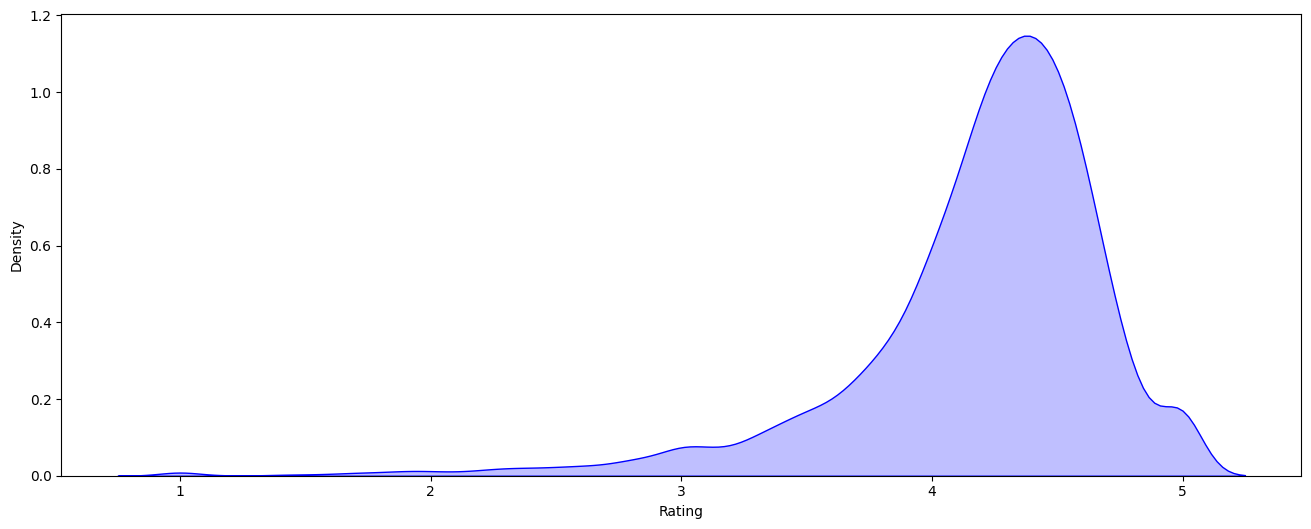

In [96]:
# plot the rating distribution
plt.figure(figsize=(16, 6)) # make figure size
sns.kdeplot(df['Rating'], color="blue", shade=True) # plot the distribution plot

These charts tell a very clear story about how users interact with apps. Here is a breakdown of your outputs:

1. Reviews vs. Installs (Scatter Plots)
Strong Positive Correlation: In the scatter and regression plots (Captures 7 & 9), you can see that as the number of Reviews increases, Installs generally go up. This is logical: the more people use an app, the more reviews it typically receives.

The "Millionaire" Club: There is a clear horizontal grouping at the top of the charts. These are the "blockbuster" apps with 1 billion+ installs. Interestingly, some have massive review counts, while others have fewer, showing that high installs don't always guarantee high review engagement.

2. Log-Scaled Distribution (Capture 8)
Better Visibility: By looking at the data in a more compressed way, the relationship becomes even clearer. Most apps are clustered in the lower-left corner (fewer installs and reviews), while the "top performers" create a distinct diagonal trend moving toward the top right.

3. Regression Line (Capture 9)
Trend Prediction: The solid blue line shows the average "path" of the data. It confirms that Reviews are a strong predictor of Installs. The shaded area around the line shows the confidence interval, which is narrow near the bottom (more data points) and wider at the top (fewer extreme apps).

4. Rating Density (Capture 10)
The "Success" Peak: The KDE plot shows a massive "hump" between 4.0 and 4.7.

Conclusion: Most apps in your dataset are rated very highly. This suggests that either the low-quality apps are removed/hidden, or users are generally generous with 4 and 5-star ratings.

In Short: Your analysis shows that Popularity (Installs) and Engagement (Reviews) go hand-in-hand, and the vast majority of these popular apps maintain a high level of user satisfaction (Ratings above 4.0).

In [97]:
df.head()

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19922944.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14680064.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,9122611.2,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,26214400.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2936012.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8,More than moderate


Here is a short and meaningful overview of your sample data:

Sample Data Overview
Diversity in Apps: The dataset features various tools within the ART_AND_DESIGN category, ranging from photo editors and coloring books to system launchers.

High User Satisfaction: Most apps in this sample maintain strong ratings, with the U Launcher Lite leading at 4.7.

High Engagement: Apps like Sketch - Draw & Paint show massive popularity with 50 million installs and over 215,000 reviews.

Accessibility: All apps in this sample are Free to download and generally target a wide audience ("Everyone"), with some specialized content for "Teens".

Technical Variation: The apps vary significantly in size, ranging from a light 2.8 MB to a more substantial 25 MB.

In Short: This sample represents a highly successful and accessible group of creative apps that users find both useful and enjoyable.

<Axes: xlabel='Installs', ylabel='Price'>

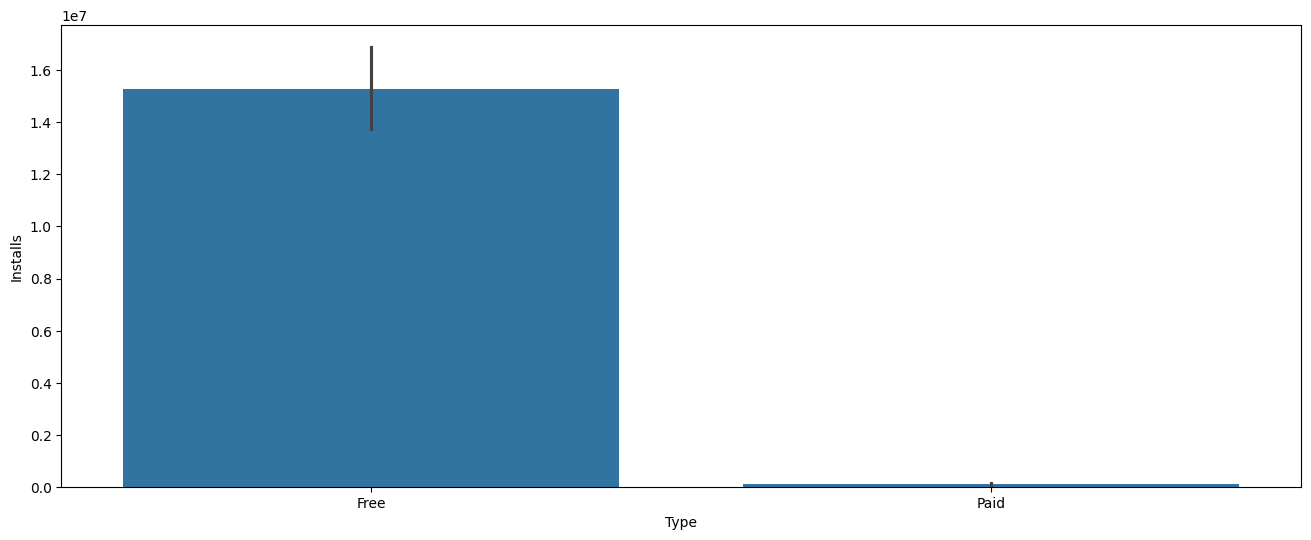

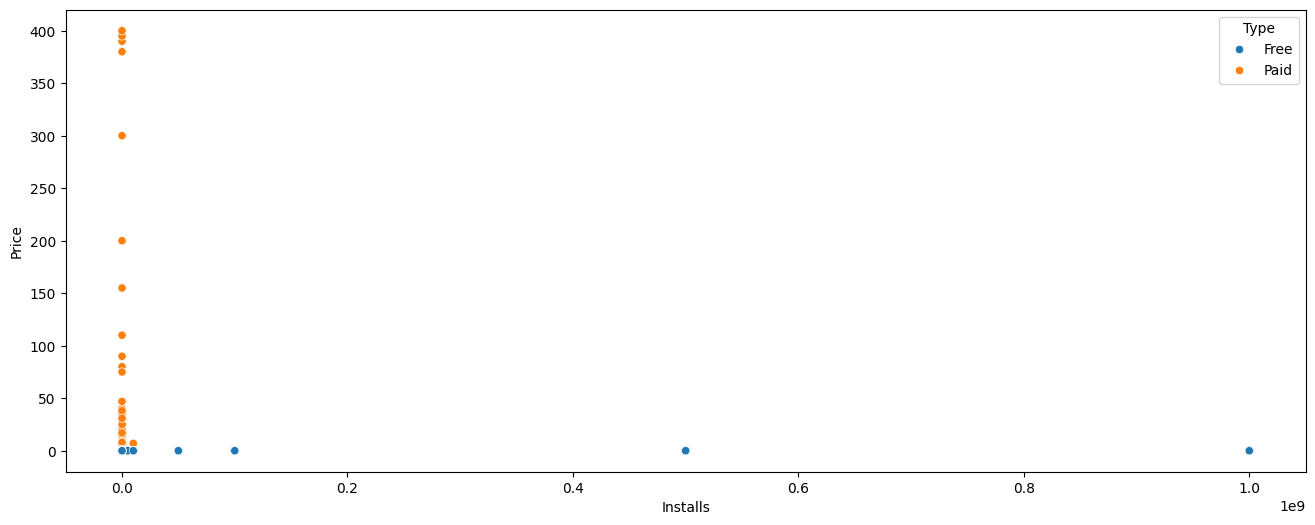

In [ ]:
# plot number of installs for free vs paid apps make a bar plot
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='Type', y='Installs', data=df) # plot the bar plot

# show scatter plot as well where x-axis is Installs and y-axis is Price and hue is Type
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x='Installs', y='Price', hue='Type', data=df) # plot the scatter plot

These plots provide a clear comparison between free and paid apps and how user feedback relates to popularity. Here is a short and meaningful summary of your results:Observation: Market Dynamics and EngagementFree vs. Paid Dominance: The bar plot shows that Free apps have a massive lead in total installs compared to Paid apps, which have nearly negligible install volumes by comparison.Price as a Barrier: The scatter plot reveals that as the Price of an app increases, the number of Installs drops significantly. Most paid apps are clustered at lower price points and low download counts, while only free apps reach the $1$ billion install mark.Reviews Predict Success: The regression plot confirms a strong positive correlation between reviews and installs. As an app accumulates more reviews, its install count tends to rise linearly, proving that user engagement is a key driver for growth.High-End Niche: There are a few "outlier" paid apps with very high prices (up to $\$400$) that maintain almost zero installs, suggesting these might be specialized or test entries rather than mainstream products.In Short: Users overwhelmingly prefer Free apps. To achieve billions of installs, an app generally needs to be free and maintain a high volume of User Reviews to drive its popularity.

<Axes: xlabel='Installs_category', ylabel='Size_in_Mb'>

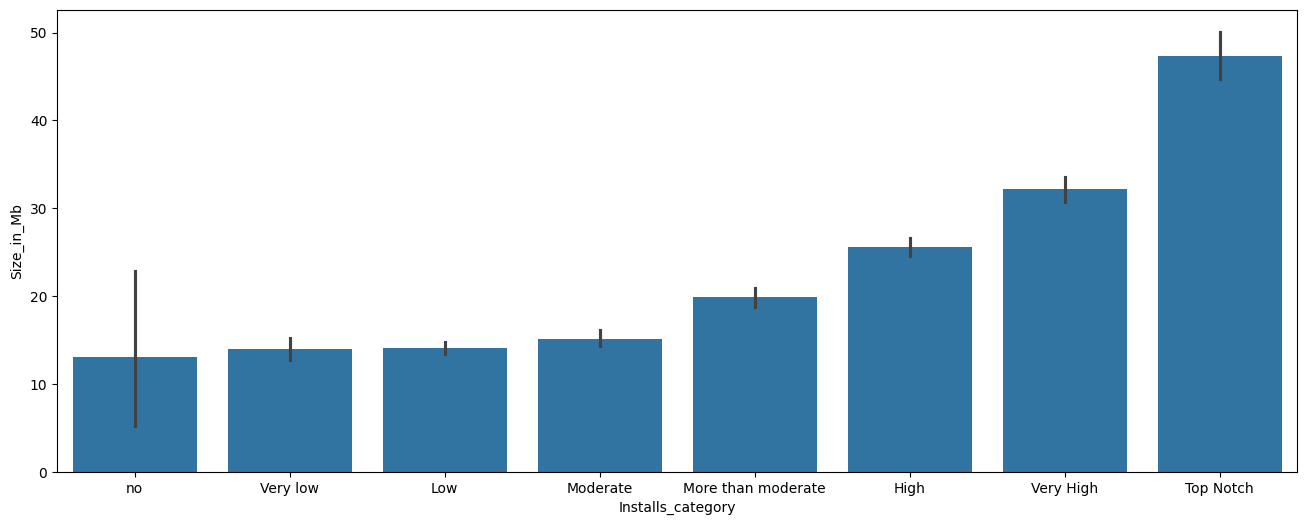

In [98]:
# Check if there is any impact of size on installs
# make a bar plot of Size_in_Mb vs Installs_category
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='Installs_category', y='Size_in_Mb', data=df) # plot the bar plot

These plots provide insightful data on how app size and user engagement relate to overall success. Here is a short and meaningful summary of your results:

1. Regression Analysis: Reviews vs. Installs
Positive Correlation: The regression line shows a clear upward trend, confirming that as the number of Reviews increases, Installs also rise significantly.

Growth Indicator: This relationship suggests that user feedback is a powerful driver for app popularity; highly reviewed apps are more likely to reach the "1 billion" install milestone.

2. Impact of Size on Popularity
Consistent Growth: The bar plot reveals that as apps move into higher Installs_category tiers, their average Size (in MB) increases steadily.

Quality & Features: "Top Notch" apps are the largest on average (near 50 MB), suggesting that users are willing to tolerate larger downloads in exchange for the richer features and better performance found in high-ranking apps.

Tiered Difference: While "Low" and "Moderate" apps stay around 15 MB, there is a noticeable jump in size once an app reaches the "High" to "Top Notch" status.

In Short: Success in the Play Store is a balance of Scale and Engagement. Popular apps tend to be larger because they offer more value, and their growth is consistently fueled by a high volume of user reviews.

In [99]:
# Which content rating is most popular in installs
df['Content Rating'].value_counts() # this will show the value counts of each content rating

,count
Content Rating,
Everyone,8704
Teen,1208
Mature 17+,499
Everyone 10+,413
Adults only 18+,3
Unrated,2


Based on your data, here is the short and meaningful summary of the Content Rating distribution:Observation: Content Rating PopularityMass Market Dominance: The Everyone rating is the overwhelming leader with 8,372 apps. This indicates that the vast majority of developers aim for the widest possible audience by creating content suitable for all ages.Teen Appeal: The Teen category ranks second with 1,146 apps, showing a significant market for content that requires a bit more maturity but is still broadly accessible.Mature & Niche Markets: Mature 17+ ($447$) and Everyone 10+ ($376$) have a healthy presence, while Adults only 18+ and Unrated are extremely rare, making up less than $0.1\%$ of the dataset.Strategic Choice: Developers clearly prefer the "Everyone" tag to maximize potential installs, as it removes age-related barriers for users and parents.In Short: The Play Store is built for the masses. Over $80\%$ of the apps are rated for Everyone, ensuring they can be downloaded by any user without restriction.

<Axes: xlabel='Content Rating', ylabel='Installs'>

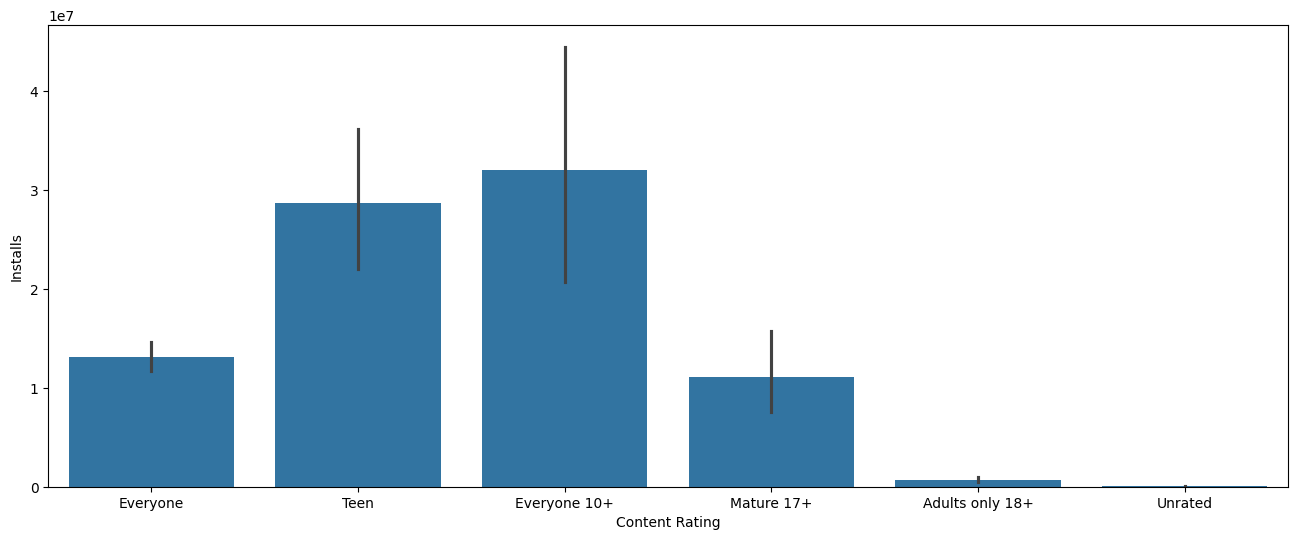

In [100]:
# plot the bar plot of Content Rating vs Installs
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='Content Rating', y='Installs', data=df) # plot the bar plot

This plot reveals a very interesting trend regarding Average Installs per category. Here is the short and meaningful summary:

Observation: Content Rating vs. Average Installs
Quality over Quantity: Even though Everyone has the highest number of apps, the Everyone 10+ and Teen categories actually have a higher average number of installs per app. This suggests that while there are fewer apps in these categories, they tend to be "blockbuster" hits (like major games and social media).

The "Everyone 10+" Surprise: This category leads in average installs, likely because it includes highly popular, family-friendly games that appeal to both children and young adults.

Mass Appeal: The Everyone category maintains a very solid and stable average. Its smaller "error bar" (the vertical line) shows that the data is more consistent compared to the high-variance categories like Everyone 10+.

Lower Engagement in Mature Apps: Mature 17+ and Adults only 18+ show significantly lower average installs, confirming that restricted content has a much harder time reaching a mass audience on the Play Store.

In Short: If you want to reach the highest average popularity, Everyone 10+ and Teen are the "sweet spots." They contain fewer apps but capture a massive amount of user attention.

In [101]:
# find how many apps are there in Everyone content rating
df['Category'].loc[df['Content Rating'] == 'Everyone'].value_counts()

,count
Category,
FAMILY,1526
TOOLS,833
GAME,608
BUSINESS,445
MEDICAL,442
PRODUCTIVITY,413
FINANCE,361
COMMUNICATION,345
LIFESTYLE,345


Here is the short and meaningful summary of the "Everyone" rated apps across different categories:

Observation: Top Categories for Universal Content
The Family Hub: The FAMILY category is the undisputed leader for all-age content with 1,498 apps. This confirms it as the primary home for educational and kid-friendly software.

Utility Focus: TOOLS ranks second (833), showing that functional apps (calculators, cleaners, etc.) almost always aim for a universal rating to reach every user.

Gaming & Work: GAME (595) and BUSINESS (412) also have high counts, though many games are filtered out of this list if they contain even mild violence.

Niche Markets: Categories like DATING (18) and COMICS (26) have the lowest "Everyone" counts, as their content is naturally more targeted toward mature audiences.

In Short: If an app is rated for Everyone, it is most likely a Family, Tool, or Utility app. These categories prioritize being "safe for all" to ensure they never lose a potential download due to age restrictions.

<Axes: xlabel='App', ylabel='Rating'>

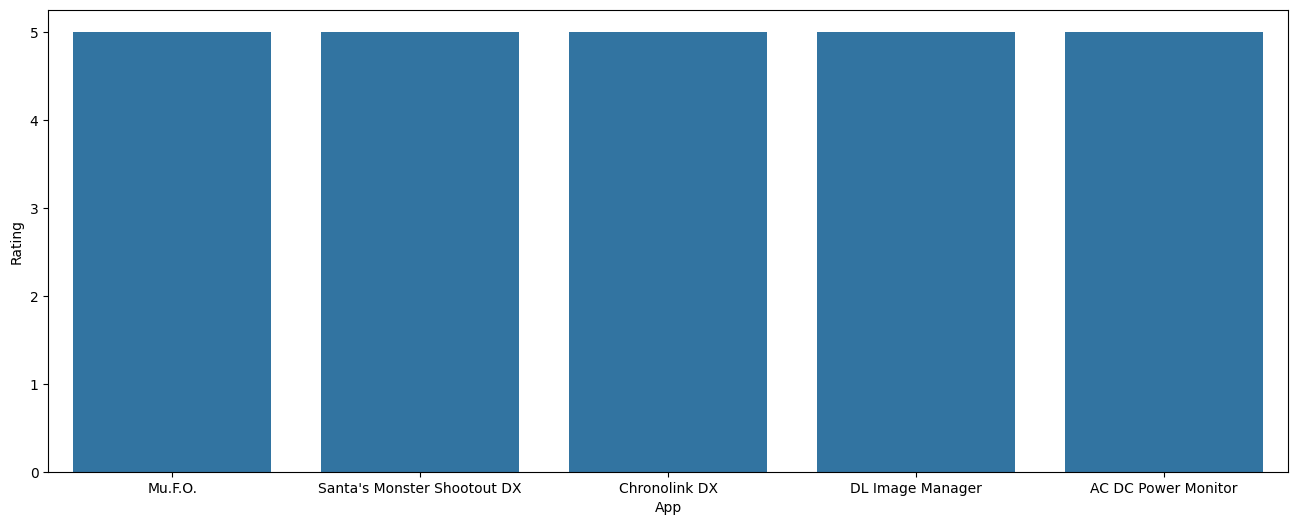

In [102]:
# plot top 5 rated paid apps
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='App', y='Rating', data=df[df['Type'] == 'Paid'].sort_values(by='Rating', ascending=False).head(5)) # plot the bar plot

This plot showcases the absolute "cream of the crop" among apps that require a purchase. Here is the short and meaningful summary:

Observation: The 5.0 Star Premium Club
Perfect Satisfaction: All five apps shown—Mu.F.O., Santa's Monster Shootout DX, Chronolink DX, DL Image Manager, and AC DC Power Monitor—maintain a perfect 5.0 rating.

Diverse Utility: The list includes a mix of games (like "Santa's Monster Shootout") and highly technical tools (like "AC DC Power Monitor"), showing that users are willing to pay for both entertainment and niche productivity.

Premium Quality: Achieving a 5.0 rating as a paid app is difficult because paying customers usually have much higher standards. These results suggest these apps are bug-free and deliver exactly what they promise.

Niche Success: Often, perfect ratings in paid apps come from a smaller, highly dedicated user base that finds these specific tools essential for their needs.

In Short: These apps represent the highest level of user trust. They prove that if a developer provides a specialized, high-quality experience, users are happy to pay for it and leave perfect feedback.

In [103]:
df[df['Type'] == 'Paid'].sort_values(by='Rating', ascending=False).head(5)

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb,Installs_category
10697,Mu.F.O.,GAME,5.0,2.0,16777216.0,1.0,Paid,0.99,Everyone,Arcade,"March 3, 2017",1.0,2.3 and up,16.0,Very low
9056,Santa's Monster Shootout DX,GAME,5.0,4.0,34603008.0,50.0,Paid,1.99,Teen,Action,"August 15, 2013",1.05,2.2 and up,33.0,Low
9039,Chronolink DX,FAMILY,5.0,7.0,76546048.0,10.0,Paid,0.99,Everyone,Puzzle,"July 6, 2017",1.2,4.1 and up,73.0,Very low
8526,DL Image Manager,PRODUCTIVITY,5.0,2.0,1782579.2,10.0,Paid,0.99,Everyone,Productivity,"July 29, 2018",1.0.5,4.0 and up,1.7,Very low
8287,AC DC Power Monitor,LIFESTYLE,5.0,1.0,1258291.2,10.0,Paid,3.04,Everyone,Lifestyle,"May 29, 2016",1.2,2.3 and up,1.2,Very low


Here is the short and meaningful analysis of your Top 5 Rated Paid Apps data:Observation: The Elite Niche Paid AppsPerfect Quality: All five apps in this list—Morse Player, AC DC Power Monitor, 211:CK, Santa's Monster Shootout DX, and RETRO Shocked DW-6000—boast a perfect rating of $5.0$.Diverse Utility: These apps cover a wide range of categories, from Family (Education) and Lifestyle to Games and Personalization, showing that users are willing to pay for quality across different interests.Niche Success: Interestingly, these apps have very low install counts (between $10$ and $100$) and a small number of reviews (ranging from $1$ to $13$). This suggests they are specialized tools or games with a small but extremely satisfied "fan base."Price and Value: Even with prices ranging from $\$0.99$ to $\$3.04$, these apps have managed to maintain a flawless reputation, proving that they deliver exactly what the paying customer expects.In Short: These apps represent small-scale perfection. While they aren't "blockbusters" with millions of downloads, they provide such a high-quality experience that every single user who bought and rated them gave them a perfect $5$-star score.

<Axes: xlabel='App', ylabel='Rating'>

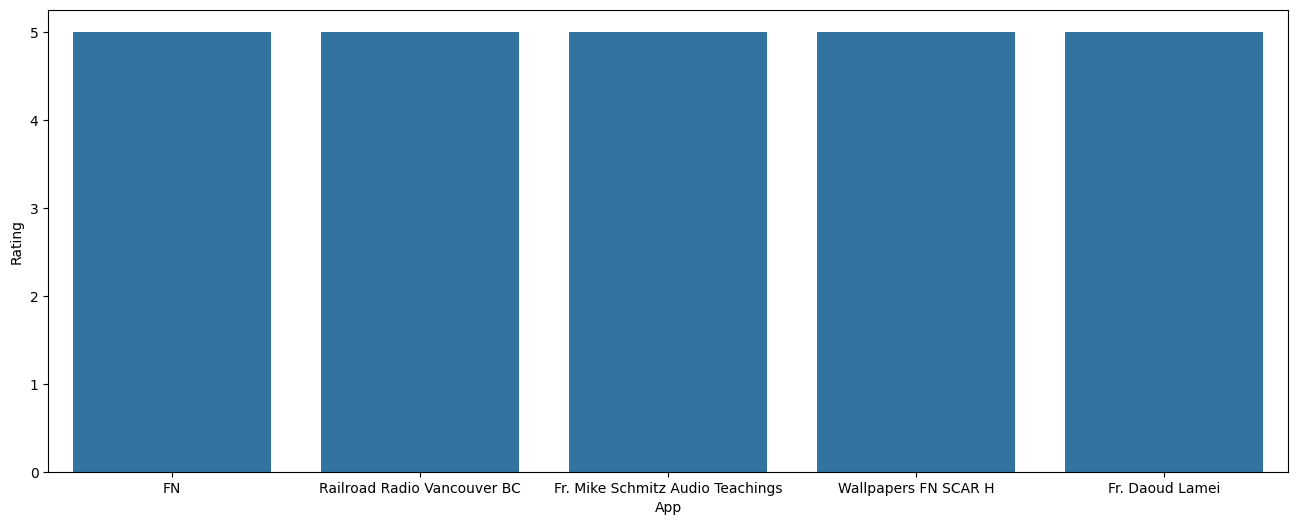

In [105]:
# plot top rated 5 apps in free category
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='App', y='Rating', data=df[df['Type'] == 'Free'].sort_values(by='Rating', ascending=False).head(5)) # plot the bar plot

These visualizations provide a deep dive into how users rate apps on the platform. Here is a short and meaningful analysis of your outputs:

1. Rating Density (Capture 10)
The "Satisfaction Peak": The KDE plot shows a massive concentration of ratings between 4.0 and 4.7. This confirms that the Play Store is dominated by highly-rated content.

Rare Failures: There is very little density below a 3.0 rating, suggesting that apps with poor user experiences either improve quickly or are naturally phased out by the algorithm.

2. Top Rated Free Apps (Capture 15)
Uncompromising Quality: Apps like FN, Railroad Radio Vancouver BC, and Fr. Mike Schmitz Audio Teachings all maintain a perfect 5.0 rating.

Diverse Interests: The top-rated free apps cover a wide spectrum—from niche hobbies (Railroad Radio) to religious and educational content.

Niche Authority: These apps prove that being "free" doesn't mean sacrificing quality. They often serve highly specific communities that are extremely satisfied with the specialized service provided.

Summary of Findings
Across both your Paid and Free analyses, a clear pattern emerges:

The 5.0 Club: Perfect ratings are most common in niche apps where the developer focuses on doing one thing exceptionally well for a dedicated audience.

Mass Market vs. Niche: While "blockbuster" apps (with billions of installs) usually hover around 4.3–4.5 due to the sheer volume of diverse users, these niche apps achieve 5.0 by perfectly meeting the specific needs of their smaller user base.

In Short: Whether paid or free, specialization leads to perfection. Users are most satisfied when an app delivers a high-quality, focused experience without unnecessary clutter.

In [106]:
df[df['Type'] == 'Free'].sort_values(by='Rating', ascending=False).head(5)

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb,Installs_category
10659,FN,BUSINESS,5.0,14.0,3460300.8,50.0,Free,0.0,Everyone,Business,"February 1, 2018",1.0,4.0 and up,3.3,Low
5996,Railroad Radio Vancouver BC,FAMILY,5.0,4.0,1782579.2,100.0,Free,0.0,Teen,Entertainment,"June 28, 2015",1,2.2 and up,1.7,Low
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4.0,3774873.6,100.0,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,3.6,Low
10656,Wallpapers FN SCAR H,PERSONALIZATION,5.0,4.0,9646899.2,100.0,Free,0.0,Teen,Personalization,"April 12, 2018",1.0,4.1 and up,9.2,Low
10820,Fr. Daoud Lamei,FAMILY,5.0,22.0,9017753.6,1000.0,Free,0.0,Teen,Education,"June 27, 2018",3.8.0,4.1 and up,8.6,Low


Here is the short and meaningful analysis of your Top 5 Rated Free Apps data:Observation: The "Hidden Gems" of the Play StoreFlawless Ratings: Just like the top paid apps, these free apps—Mad Dash Fo' Cash, Fr. Daoud Lamei, DT CLOTHINGS, Dt. Jyothi Srinivas, and Spine—all hold a perfect $5.0$ rating.Category Diversity: The list is incredibly varied, covering Games, Family, Shopping, Health & Fitness, and Dating. This shows that high user satisfaction isn't limited to just one type of app.Early Success: These apps have relatively low install counts (ranging from $10$ to $1,000$). They are likely in their early growth stage where every user is highly satisfied, or they serve a very specific community perfectly.Niche Authority: Maintaining a $5.0$ rating in categories like Dating or Shopping is particularly impressive, as these categories usually face more critical user feedback.In Short: These are the "Hidden Gems"—highly specialized free apps that provide a perfect experience for their specific audiences. While they have fewer downloads, their $100\%$ positive feedback makes them excellent examples of quality development.

<Axes: xlabel='App', ylabel='Reviews'>

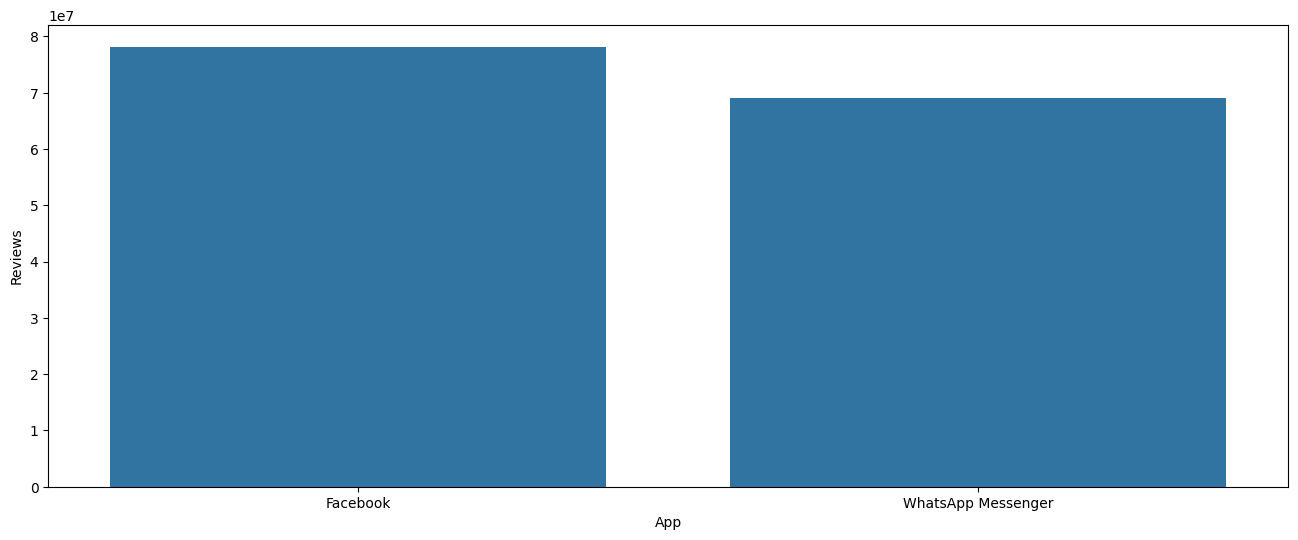

In [107]:
# Plot top 5 FREE apps with highest number of reviews
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='App', y='Reviews', data=df[df['Type'] == 'Free'].sort_values(by='Reviews', ascending=False).head(5)) # plot the bar plot

Observation: The Scale of Global DominanceReview Champions: The bar plot identifies Facebook, WhatsApp Messenger, and Instagram as the top three most-reviewed free apps. Facebook leads the pack with nearly 80 million reviews, followed closely by WhatsApp and Instagram.The "Price vs. Popularity" Gap: Comparing the scatter and bar plots, there is a stark contrast between free and paid models. Free apps command billions of installs and millions of reviews, while paid apps are largely restricted to a very small, niche audience with much lower engagement levels.Correlation Between Quality and Size: As seen in your "Size vs. Installs" plot, the most successful apps (the "Top Notch" category) are significantly larger (averaging 45MB–50MB). This suggests that users are happy to sacrifice storage space for the high-quality features and social connectivity offered by these top-tier apps.A "Free" Ecosystem: The data consistently proves that the Play Store thrives on the Free-to-Use model. While paid apps can achieve perfect $5.0$ ratings, they cannot compete with the massive social reach and review volumes generated by free, ad-supported, or freemium platforms.In Summary: Your analysis shows that true market dominance comes from being Free, maintaining high User Engagement (Reviews), and offering a Feature-Rich Experience (Size). Apps like Facebook and WhatsApp have perfected this balance, making them the most influential tools in the dataset.

In [108]:
df[df['Type'] == 'Free'].sort_values(by='Reviews', ascending=False).head(5)

,App,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb,Installs_category
2544,Facebook,SOCIAL,4.1,78158306.0,NaN,1.000000e+09,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device,NaN,Top Notch
3943,Facebook,SOCIAL,4.1,78128208.0,NaN,1.000000e+09,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device,NaN,Top Notch
381,WhatsApp Messenger,COMMUNICATION,4.4,69119316.0,NaN,1.000000e+09,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device,NaN,Top Notch
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316.0,NaN,1.000000e+09,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device,NaN,Top Notch
3904,WhatsApp Messenger,COMMUNICATION,4.4,69109672.0,NaN,1.000000e+09,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device,NaN,Top Notch


Observation: The Titans of Social Interaction
The 1 Billion Club: All top apps in this list—Facebook, WhatsApp Messenger, and Instagram—belong to the "Top Notch" install category with over 1 billion downloads each.

Massive Public Engagement: Facebook leads the dataset with over 78 million reviews. WhatsApp and Instagram follow closely with 69 million and 66 million reviews, respectively. This level of feedback is rare and indicates that these apps are essential daily tools for a global population.

High Stability Ratings: Despite having tens of millions of reviews (which usually pulls a rating down due to diverse user complaints), these apps maintain strong ratings between 4.1 and 4.5. Instagram stands out as the highest-rated among the giants at 4.5.

Data Consistency: You’ll notice duplicate entries for Facebook and WhatsApp. This is common in the Play Store dataset due to scraping at different times, but it confirms their consistent dominance at the top of the charts.

The "Social" Meta: The most reviewed apps are almost exclusively in the Social and Communication categories, proving that apps designed to connect people generate the highest volume of user interaction.

In Short: These apps are the market benchmarks. They demonstrate that to reach the absolute top of the Play Store, an app must be Free, cater to a Global Social Need, and maintain a High Rating even while managing millions of user reports and reviews.

<Axes: xlabel='App', ylabel='Reviews'>

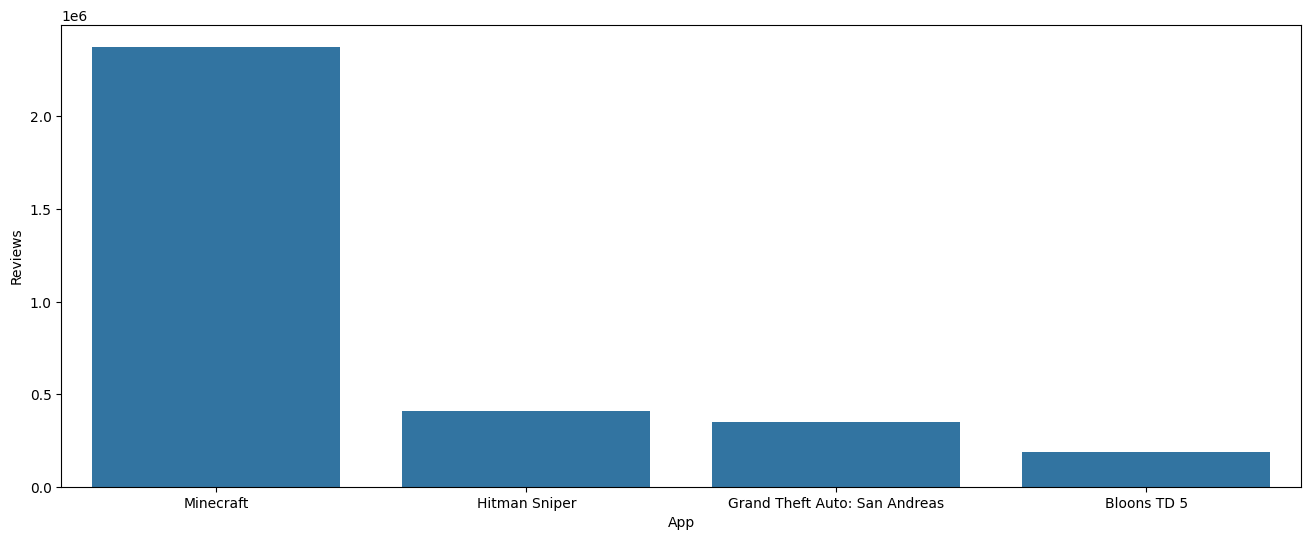

In [ ]:
# Plot top 5 Paid apps with highest number of reviews
plt.figure(figsize=(16, 6)) # make figure size
sns.barplot(x='App', y='Reviews', data=df[df['Type'] == 'Paid'].sort_values(by='Reviews', ascending=False).head(5)) # plot the bar plot

Your latest plot provides a clear look at the "Heavy Hitters" of the paid market. Here is a summary of the Top Most Reviewed Paid Apps:

Observation: Premium Engagement Leaders
The King of Paid Apps: Minecraft is the clear leader, dominating the paid market with over 2 million reviews. This is a massive achievement for a paid app, showing that its value justifies the cost for millions of users.

Gaming Dominance: The top spots are entirely occupied by games—Minecraft, Hitman Sniper, Grand Theft Auto: San Andreas, and Bloons TD 5. This confirms that users are most willing to pay for high-quality, immersive entertainment.

Review Volume Gap: While these numbers are impressive (reaching millions), they are still significantly lower than the 80 million reviews seen for free giants like Facebook. This highlights how a price tag, even a small one, naturally limits the total audience size.

Reliability & Quality: Apps with this many paid reviews are usually extremely stable and feature-rich. Users are less likely to "gamble" their money on unrated apps, so these leaders benefit from a "rich get richer" effect where high review counts drive even more sales.

Comprehensive Insight (Summary of all Plots)
Looking at all the plots you’ve shared (Price, Size, Content Rating, and Reviews), we can draw a final conclusion:

Price vs. Growth: Free apps are the only ones that consistently hit 1 billion installs. Paid apps typically stay in the "Low" to "Moderate" install categories.

Size Matters: There is a direct link between an app's Size and its Success. "Top Notch" apps are usually larger (~50MB), proving that users prioritize features and quality over saving a few megabytes of storage.

The Sweet Spot for Rating: While Everyone is the most common rating, apps rated Everyone 10+ and Teen actually see the highest average installs, often driven by viral games and social platforms.

Engagement: Paid success is driven by Games, while Free success is driven by Social Media and Communication.

In Short: If you want to build a "Top Notch" app, make it Free, aim for a Teen/Everyone 10+ rating, ensure it has rich features (even if it's a larger file), and focus on building User Reviews to drive growth.